<h1 style="text-align:center">Pothole Semantic Segmentation with Encoder-only Mask Transformer (EoMT)

<h5 style="text-align: center;"> Submitted for ARA 7.0 Data Science Competition

## Table of Contents

1. [Introduction](#Introduction)
2. [Configuration](#Configuration)
3. [Data Exploration (EDA)](#Data-Exploration-&-Analysis)
4. [Preprocessing & Augmentation](#Preprocessing-&-Augmentation)
5. [Modeling Architecture](#Modeling-Architecture)
6. [Model Training & Validation](#Model-Training-&-Validation)
7. [Inference & Post-processing](#Inference-&-Post-processing)
8. [Conclusion](#Conclusion)

# Introduction

<center>
    <img src="https://www.researchgate.net/publication/361577046/figure/fig8/AS:11431281079643342@1660788271407/Sample-outputs-of-pothole-segmentation.jpg">
    <br>Image source: <a href="https://www.researchgate.net/publication/361577046/figure/fig8/AS:11431281079643342@1660788271407/Sample-outputs-of-pothole-segmentation.jpg">Research Gate</a>
</center>

Road infrastructure is crucial for mobility, yet potholes remain as threat to public safety. Traditional manual inspections are often slow and reactive, failing to provide the real-time, objective data needed for efficient maintenance. To address this, we leverage Semantic Segmentation to classify every pixel, allowing for precise area estimation and proactive resource allocation.

The core objective of this project is to build a high-precision segmentation model capable of mapping pothole areas across diverse and challenging scenarios. The model must maintain consistency despite significant variations in road texture, pothole size, shape and image camera angles. Furthermore, it must accurately distinguish potholes from visual noise, such as shadows, minor cracks, and environmental debris. By utilizing the provided ground-truth dataset and computer vision models, this project aims to transform raw imagery into actionable infrastructure insights.

### Metrics: Dice Coefficient

Model performance is evaluated using the Dice Coefficient. This metric measures the similarity between the predicted mask and the ground truth by calculating the area of overlap. The score ranges from 0 to 1, where a higher value indicates better segmentation accuracy.

$$ \text{Dice} = \frac{2TP}{2TP + FP + FN} $$

# Configuration

### Environment Setup

In [1]:
# Install Dependencies

!pip install -q pillow pycocotools albumentations
!pip install -q -U transformers

In [2]:
# Import Libraries

import os
import random
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import albumentations as A
from glob import glob
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# EoMT-DINOv3 (HuggingFace)
from transformers import AutoImageProcessor
from transformers import EomtDinov3ForUniversalSegmentation

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_row', None)

print(f"PyTorch: {torch.__version__}")
print(f"Device: {'GPU - ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

PyTorch: 2.8.0+cu128
Device: GPU - NVIDIA RTX 6000 Ada Generation


### Paths, Training, Model, Device and Output Configuration

In [ ]:
class CFG:
    
    # Directory Paths 
    TRAIN_IMG_DIR = 'dataset/dataset/train/images'
    TRAIN_MASK_DIR = 'dataset/dataset/train/mask'
    TEST_IMG_DIR  = 'dataset/dataset/test/images'

    # Training
    IMAGE_SIZE      = 512
    BATCH_SIZE      = 4
    EPOCHS          = 12
    LEARNING_RATE   = 1e-5
    VALIDATION_SPLIT = 0.2

    # Model
    MODEL_ID = "tue-mps/eomt-dinov3-ade-semantic-large-512"

    # Device & Precision
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    NUM_WORKERS = 0
    PIN_MEMORY  = True
    USE_AMP     = False

    # Output
    MODEL_SAVE_PATH = 'best_eomt_pothole.pth'
    SUBMISSION_FILE = 'submission_eomt.csv'
    SEED = 42
    PRETRAINED_MODEL_PATH = ''

### Set Seed for Reproducibility

In [4]:
def set_seed(seed=42):
    """
    Set seed for all random components in order to achieve reproducibility.

    Args:
        seed (int): seed value that will be used.
    """

    # Python
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # OpenCV
    cv2.setRNGSeed(seed)
    cv2.setNumThreads(0)
    
    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # cuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # TF32
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    
    # SDPA (Attention)
    torch.backends.cuda.enable_flash_sdp(False)
    torch.backends.cuda.enable_mem_efficient_sdp(False)
    torch.backends.cuda.enable_math_sdp(True)
    
    # Deterministic algorithms
    torch.use_deterministic_algorithms(True, warn_only=True)
    
    # cuBLAS
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

set_seed(CFG.SEED)

# Data Exploration & Analysis

### Data Overview

The dataset is specifically curated for the ARA 7.0 Data Science Competition. It is designed for pixel-level semantic segmentation to identify road damage.

* Training set: contains road surface images and grouwth-truth masks.
* Test set: contains images for inference and submission.

In [5]:
def plot_dataset_distribution(train_count, test_count):
    """
    Automatically counts files from CFG paths and plots the distribution.

    Args:
        train_count (int): number of train images.
        test_count  (int): number of test images.
    """
    labels = ['Training Set', 'Test Set']
    sizes = [train_count, test_count]
    colors = ['#42D4C1', '#F8835E']
    
    plt.figure(figsize=(7, 5))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', 
            startangle=140, explode=(0.05, 0), shadow=True,
            textprops={'fontweight': 'bold'})
    
    plt.title(f'Dataset Split Ratio\n(Total: {train_count + test_count} Images)', 
              fontsize=14, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

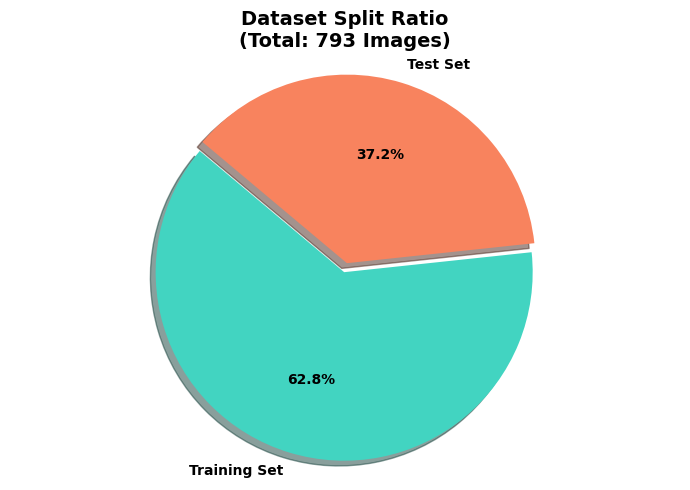

Number of train images: 498
Number of test images: 295


In [6]:
train_count = len([f for f in os.listdir(CFG.TRAIN_IMG_DIR) 
                       if os.path.isfile(os.path.join(CFG.TRAIN_IMG_DIR, f))])
test_count = len([f for f in os.listdir(CFG.TEST_IMG_DIR) 
                  if os.path.isfile(os.path.join(CFG.TEST_IMG_DIR, f))])

plot_dataset_distribution(train_count, test_count)

print(f"Number of train images: {train_count}")
print(f"Number of test images: {test_count}")

As seen above, the dataset only consists of $793$ images, with $62.8\%$ of them are train images and the rest are test images, which is relatively small for a complex semantic segmentation tasks. To achieve optimal performance, it may be necesssary to implement a robust data augmentation strategy to enhance model generalizaiton and prevent overfitting.

### Train and Test Image Sample

In [7]:
def visualize_train_batch(num=3):
    """Displays random samples from TRAIN (Image + Mask + Overlay)"""
    all_images = sorted(glob(os.path.join(CFG.TRAIN_IMG_DIR, '*')))
    
    if not all_images:
        print("Error: No images found in training directory.")
        return

    samples = random.sample(all_images, num)
    
    fig, axes = plt.subplots(num, 3, figsize=(15, 5*num))
    fig.suptitle('Training Data Check: Image vs Mask', fontsize=16)
    
    for i, img_path in enumerate(samples):
        # 1. Load Image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # 2. Load Mask (Fixed format: mask_{id}.png)
        # Extract ID (e.g., train_001 -> 001)
        img_id = os.path.basename(img_path).split('.')[0].split('_')[-1] 
        mask_path = os.path.join(CFG.TRAIN_MASK_DIR, f"mask_{img_id}.png")
        
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, 0)
        else:
            mask = np.zeros(img.shape[:2], dtype=np.uint8) # Blank if error
            print(f"Missing mask: {mask_path}")

        # 3. Create Red Overlay
        overlay = img.copy()
        # Color mask pixels with Red
        overlay[mask > 0] = (255, 0, 0) 
        # Blend for transparency (0.6 Original + 0.4 Red)
        cv2.addWeighted(overlay, 0.4, img, 0.6, 0, overlay)

        # Plotting
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Image: {os.path.basename(img_path)}")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis('off')

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("Overlay Check")
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

def visualize_test_batch(num=3):
    """Displays random samples from TEST (Unseen Data)"""
    all_images = sorted(glob(os.path.join(CFG.TEST_IMG_DIR, '*')))
    
    if not all_images:
        print("Error: No images found in test directory.")
        return

    samples = random.sample(all_images, num)
    
    fig, axes = plt.subplots(1, num, figsize=(15, 5))
    fig.suptitle('Test Data Samples (Unseen)', fontsize=16)
    
    if num == 1: axes = [axes] # Handle single sample case
    
    for i, img_path in enumerate(samples):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        axes[i].imshow(img)
        axes[i].set_title(os.path.basename(img_path))
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

Stated in the dataset description, the data characteristics vary across samples. Some are located to the center, some are huge, some have more than 1 pot holes, etc. To make sense of the holistic dataset characteristics, an in-depth analysis of the dataset is required (see next part of exploration).

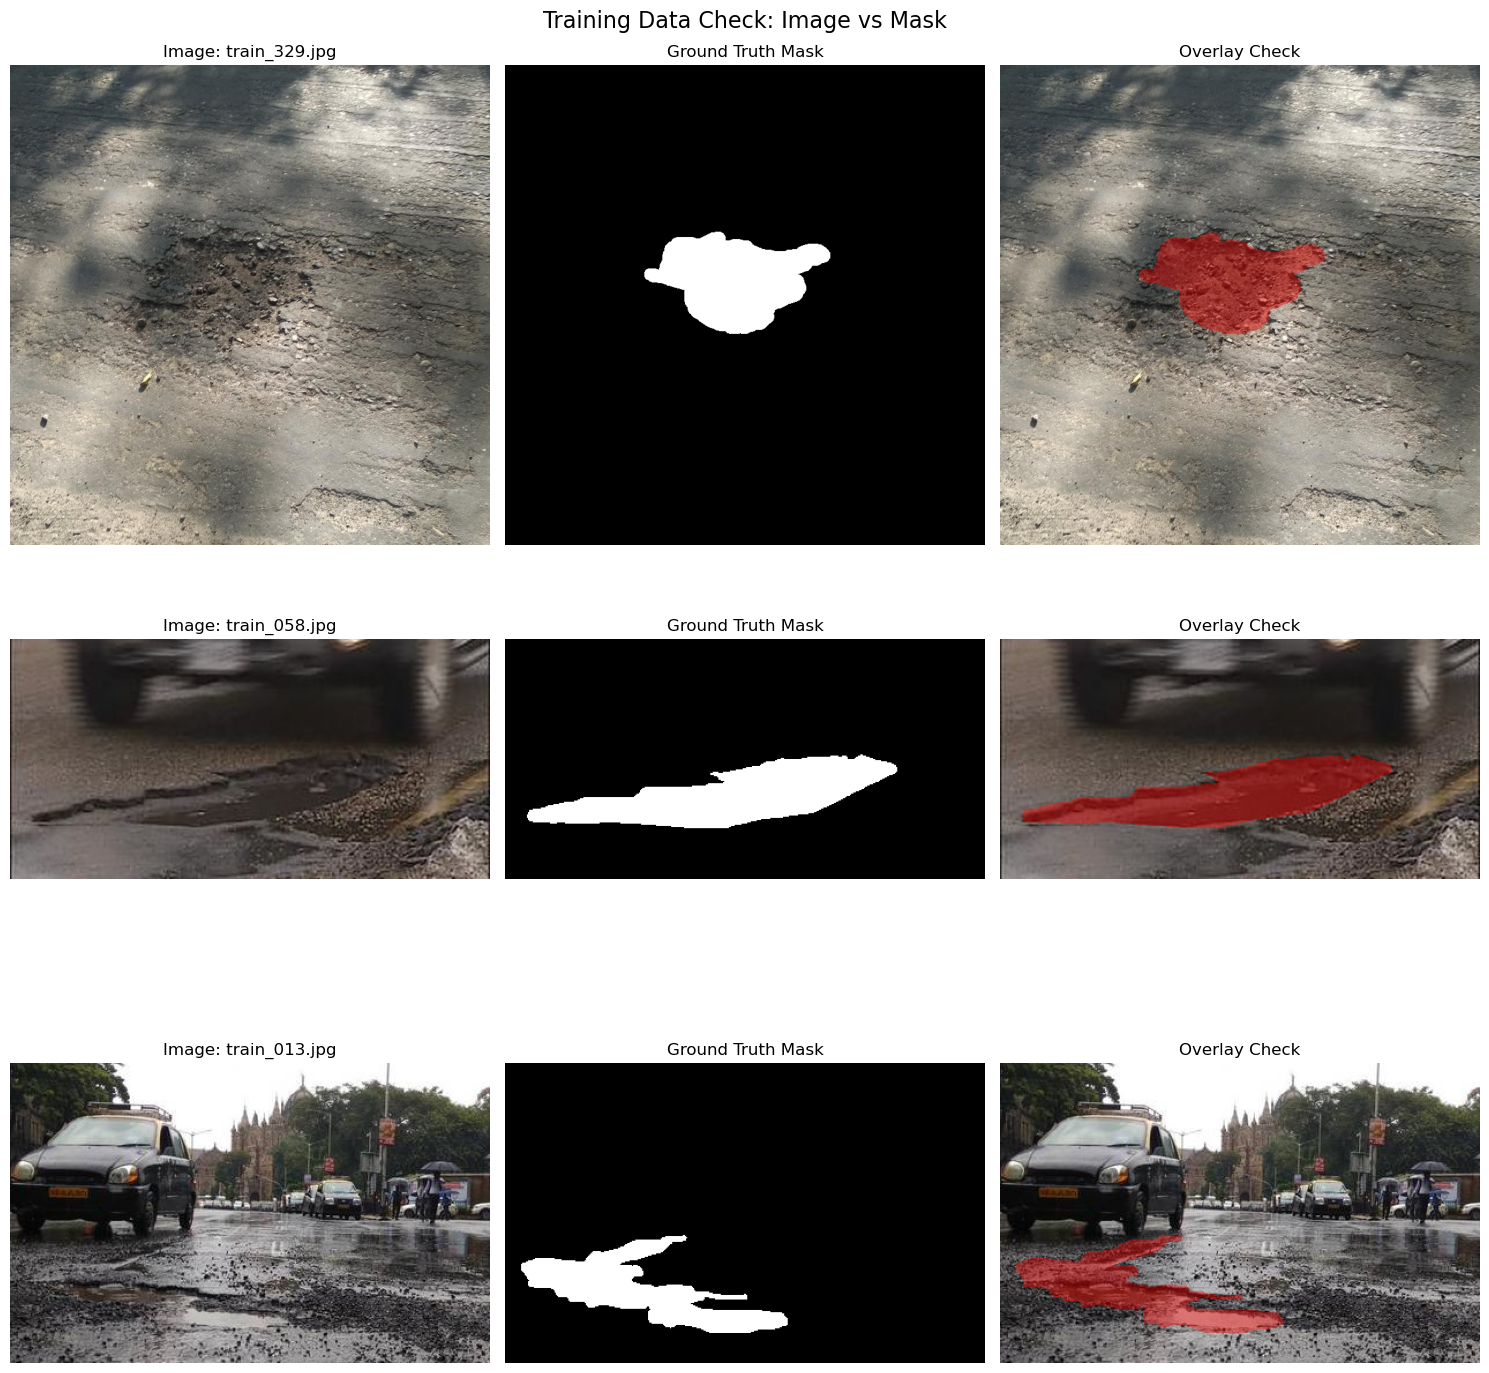

In [8]:
visualize_train_batch(3)

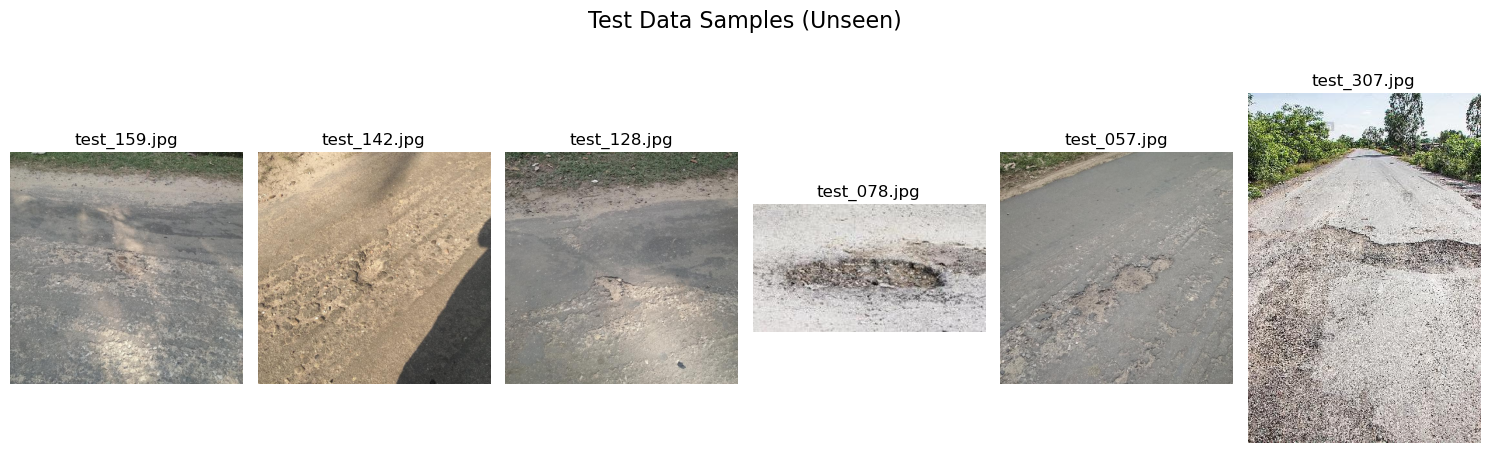

In [9]:
visualize_test_batch(6)

### In-Depth Data Exploration Analysis

#### Analysis Methods

This section transforms unstructured imagery into structured metadata to understand the dataset's characteristics. By auditing the visual health of the images and the geometric properties of the masks, we can justify our preprocessing choices and augmentation strategy. This will be done by evaluating bluriness, lighting, and many geometric profiling like pothole frequency, position, pixel density and average pothole size per image with the following methods:

1. Image Sharpness (Laplacian Variance)
    We use the Laplacian operator to calculate the second-order derivative of image brightness. High variance indicates sharp edges, while low variance suggests blurriness:
   $$\Delta I = \frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}$$
   
3. Visual Quality (Brightness & Contrast). *Note: Pi is pixel intensity*:
    - Brightness (the global mean pixel intensity):
      $$\mu = \frac{1}{N} \sum_{i=1}^{N} P_i$$
    - Contrast (image moments):
      $$\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (P_i - \mu)^2}$$
4. Spatial Centroids (location of pothole's centroid):
   $$\bar{x} = \frac{M_{10}}{M_{00}}, \quad \bar{y} = \frac{M_{01}}{M_{00}}$$
   $$M_{ij} = \sum_{x} \sum_{y} x^i y^j I(x,y)$$
5. Pothole Frequency Count: use Connected Component Analysis (cv2.connectedComponents) to count number of distinct pothole regions (white pixel islands) appearing in a single image.

6. Pixel Density:

   $$ \text{Density (\%)} = \left( \frac{\text{Total Pothole Pixels}}{H \times W} \right) \times 100 $$

7. Average Pothole Size:

   $$ \text{Avg Size} = \frac{\text{Total Pothole Pixels}}{\text{Pothole Count}} $$

In [10]:
class DatasetAuditor:
    """A utility class for deep analysis of road surface images and pothole masks."""

    def __init__(self, config):
        """
        Initializes the auditor with a configuration object.
        
        Args:
            config: An object containing paths like TRAIN_IMG_DIR, etc.
        """
        self.cfg = config

    def analyze_directory(self, image_dir, mask_dir=None, dataset_type='train'):
        """Analyzes a directory of images and corresponding masks for visual and geometric metrics.

        Args:
            image_dir (str): Path to the directory containing images.
            mask_dir (str, optional): Path to the directory containing masks. Defaults to None.
            dataset_type (str): Label for the dataset (e.g., 'train', 'test'). Defaults to 'train'.

        Returns:
            pd.DataFrame: A DataFrame containing audit metrics for each image.
        """
        data = []
        extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.JPG']
        img_paths = []
        
        for ext in extensions:
            img_paths.extend(glob(os.path.join(image_dir, ext)))
        
        img_paths = sorted(img_paths)
        print(f"Processing {dataset_type.upper()}: Found {len(img_paths)} images...")

        for img_path in tqdm(img_paths, desc=f"Analyzing {dataset_type}"):
            filename = os.path.basename(img_path)
            img_basename = os.path.splitext(filename)[0]
            
            # Load and convert image to grayscale for metric calculation
            img = cv2.imread(img_path)
            if img is None: continue
                
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            h, w = gray.shape
            
            # Calculate Visual Metrics
            blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
            brightness = np.mean(gray)
            contrast = np.std(gray)
            
            row = {
                'dataset': dataset_type,
                'filename': filename,
                'height': h, 'width': w,
                'blur_score': round(blur_score, 2),
                'brightness': round(brightness, 2),
                'contrast': round(contrast, 2),
                'pothole_count': 0, 'total_pothole_area_px': 0,
                'pothole_density_pct': 0.0, 'has_pothole': 0,
                'centroid_x': None, 'centroid_y': None
            }
            
            # Geometric Metrics from Masks
            if mask_dir:
                mask_path = self._find_matching_mask(img_basename, mask_dir)
                
                if mask_path:
                    mask = cv2.imread(mask_path, 0)
                    _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
                    
                    # Connected components for pothole statistics
                    num_labels, _, _, _ = cv2.connectedComponentsWithStats(mask_bin, connectivity=8)
                    pothole_count = num_labels - 1
                    total_area = np.count_nonzero(mask_bin)
                    density = (total_area / (h * w)) * 100
                    
                    # Calculate Normalized Centroids (0.0 to 1.0)
                    cx, cy = None, None
                    if pothole_count > 0:
                        moms = cv2.moments(mask_bin)
                        if moms["m00"] != 0:
                            cx = (moms["m10"] / moms["m00"]) / w
                            cy = (moms["m01"] / moms["m00"]) / h
                    
                    row.update({
                        'pothole_count': pothole_count,
                        'total_pothole_area_px': total_area,
                        'pothole_density_pct': round(density, 4),
                        'has_pothole': 1 if pothole_count > 0 else 0,
                        'centroid_x': cx, 'centroid_y': cy
                    })
                else:
                    row['has_pothole'] = -1  # Mask not found

            data.append(row)

        return pd.DataFrame(data)

    def _find_matching_mask(self, img_basename, mask_dir):
        """Helper to match image filename with mask filename using multiple patterns."""
        img_id = img_basename.split("_")[-1] if "_" in img_basename else img_basename
        candidates = [f"mask_{img_id}", img_basename, f"mask_{img_basename}"]
        
        for cand in candidates:
            for ext in ['.png', '.jpg', '.jpeg', '.bmp']:
                path = os.path.join(mask_dir, cand + ext)
                if os.path.exists(path):
                    return path
        return None

In [11]:
auditor = DatasetAuditor(CFG)
df_train = auditor.analyze_directory(CFG.TRAIN_IMG_DIR, mask_dir=CFG.TRAIN_MASK_DIR, dataset_type='train')
df_test = auditor.analyze_directory(CFG.TEST_IMG_DIR, dataset_type='test')

Processing TRAIN: Found 498 images...


Analyzing train:   0%|          | 0/498 [00:00<?, ?it/s]

Processing TEST: Found 295 images...


Analyzing test:   0%|          | 0/295 [00:00<?, ?it/s]

The followings are the structured form of all images' metadata those are going to be used for analysis and preprocessing decisions. You may change the value of start and end image on the following cell and run the df_train and df_test cells to see selected images analyses.

In [12]:
# Change the following start and end value of train or test images to view their metadata below.

# Train Image: 1 - 498
train_start = 1
train_end = 20

# Test Image: 1 - 295
test_start = 1
test_end = 20

In [13]:
df_train[train_start-1:train_end]

,dataset,filename,height,width,blur_score,brightness,contrast,pothole_count,total_pothole_area_px,pothole_density_pct,has_pothole,centroid_x,centroid_y
0,train,train_001.jpg,2296,4080,76.36,115.31,58.96,8,1418578,15.1433,1,0.445268,0.829664
1,train,train_002.jpg,720,720,4057.02,142.90,28.91,21,102806,19.8314,1,0.567490,0.702243
2,train,train_003.jpg,720,720,3392.70,131.13,42.12,6,103757,20.0149,1,0.473370,0.511396
3,train,train_004.jpg,400,600,824.68,93.52,53.02,4,7923,3.3013,1,0.644918,0.625369
4,train,train_005.jpg,312,416,593.87,152.98,47.48,12,27403,21.1130,1,0.376197,0.469173
5,train,train_006.jpg,720,720,1984.76,142.35,29.94,3,110620,21.3387,1,0.513682,0.792347
6,train,train_007.jpg,225,400,2004.65,95.63,47.02,2,21588,23.9867,1,0.501924,0.521061
7,train,train_008.jpg,4000,3000,199.44,137.76,41.19,1,1508063,12.5672,1,0.641230,0.466470
8,train,train_009.jpg,733,1100,1100.14,124.80,41.38,3,143010,17.7366,1,0.448746,0.561463
9,train,train_010.jpg,312,416,2453.02,115.50,64.79,1,39257,30.2461,1,0.550245,0.839063


In [14]:
df_test[test_start-1:test_end]

,dataset,filename,height,width,blur_score,brightness,contrast,pothole_count,total_pothole_area_px,pothole_density_pct,has_pothole,centroid_x,centroid_y
0,test,test_001.jpg,300,533,1362.58,130.81,46.42,0,0,0.0,0,None,None
1,test,test_002.jpg,720,720,576.12,123.89,33.73,0,0,0.0,0,None,None
2,test,test_003.jpg,2296,4080,168.16,122.68,61.58,0,0,0.0,0,None,None
3,test,test_004.jpg,300,533,831.85,121.85,31.75,0,0,0.0,0,None,None
4,test,test_005.jpg,300,400,5376.94,81.75,60.64,0,0,0.0,0,None,None
5,test,test_006.jpg,300,400,7171.67,87.76,51.11,0,0,0.0,0,None,None
6,test,test_007.jpg,300,533,985.45,121.26,50.67,0,0,0.0,0,None,None
7,test,test_008.jpg,300,571,8283.45,130.66,53.89,0,0,0.0,0,None,None
8,test,test_009.jpg,300,450,5497.52,125.86,60.90,0,0,0.0,0,None,None
9,test,test_010.jpg,300,465,2050.94,98.65,71.05,0,0,0.0,0,None,None


#### Analysis Plots and Statistics

In [15]:
def create_enhanced_bins(df):
    """
    Enriches the dataframe with categorical bins for visualization purposes.
    
    This function converts continuous metrics (like pothole count, density, 
    blur score) into readable categories (e.g., 'Low', 'High', 'Blurry') 
    to facilitate grouped analysis.

    Args:
        df (pd.DataFrame): The raw dataframe containing audit metrics.

    Returns:
        pd.DataFrame: A copy of the dataframe with new categorical columns added.
    """
    df_binned = df.copy()
    
    # 1. Ensure numeric types for critical columns
    cols_to_fix = ['pothole_count', 'pothole_density_pct', 'total_pothole_area_px', 'blur_score', 'brightness']
    for col in cols_to_fix:
        if col in df_binned.columns:
            df_binned[col] = pd.to_numeric(df_binned[col], errors='coerce')

    # 2. Feature Engineering: Average Pothole Size
    # Avoid division by zero: if count is 0, replace with 1 (result will be handled later)
    if 'total_pothole_area_px' in df_binned.columns and 'pothole_count' in df_binned.columns:
        df_binned['avg_pothole_size_px'] = df_binned['total_pothole_area_px'] / df_binned['pothole_count'].replace(0, 1)
        # Explicitly set average size to 0 where count is 0
        df_binned.loc[df_binned['pothole_count'] == 0, 'avg_pothole_size_px'] = 0
    
    # BINNING LOGIC
    
    # A. Size Categories (Based on pixel area)
    if 'avg_pothole_size_px' in df_binned.columns:
        df_binned['cat_avg_size'] = pd.cut(
            df_binned['avg_pothole_size_px'], 
            bins=[-1, 0, 500, 5000, 10000000], 
            labels=['None', 'Tiny (<500px)', 'Medium', 'Large (>5000px)']
        )
    
    # B. Frequency Categories (Count per image)
    if 'pothole_count' in df_binned.columns:
        df_binned['cat_pothole_count'] = pd.cut(
            df_binned['pothole_count'], 
            bins=[-1, 0, 2, 5, 20, 1000], 
            labels=['None (0)', 'Low (1-2)', 'Medium (3-5)', 'High (6-20)', 'Extreme (>20)']
        )
    
    # C. Density Categories (% of image area)
    if 'pothole_density_pct' in df_binned.columns:
        df_binned['cat_density'] = pd.cut(
            df_binned['pothole_density_pct'], 
            bins=[-0.1, 0, 1, 5, 100], 
            labels=['None', 'Low (<1%)', 'Medium (1-5%)', 'High (>5%)']
        )
    
    # D. Sharpness Categories (Laplacian Variance)
    if 'blur_score' in df_binned.columns:
        df_binned['cat_blur'] = pd.cut(
            df_binned['blur_score'], 
            bins=[-1, 100, 500, 100000], 
            labels=['Blurry (<100)', 'Normal (100-500)', 'Sharp (>500)']
        )
    
    # E. Lighting Categories (Mean Brightness)
    if 'brightness' in df_binned.columns:
        df_binned['cat_brightness'] = pd.cut(
            df_binned['brightness'], 
            bins=[-1, 50, 200, 256], 
            labels=['Dark (<50)', 'Normal (50-200)', 'Bright (>200)']
        )
    
    return df_binned

In [16]:
df_final = pd.concat([df_train, df_test], ignore_index=True)
df_audited = create_enhanced_bins(df_final)
train_subset = df_audited[df_audited['dataset'] == 'train']

In [17]:
def plot_categorical_dist(df, col, title, palette='viridis'):
    """Plots both a bar chart and a pie chart for a categorical column.

    Args:
        df (pd.DataFrame): The dataframe containing the data.
        col (str): The column name to visualize.
        title (str): The main title of the figure.
        palette (str): Seaborn color palette to use. Defaults to 'viridis'.
    """
    counts = df[col].value_counts().sort_index()
    total = counts.sum()
    if total == 0: 
        print(f"No data available for column: {col}")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    # Bar Chart 
    sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette=palette)
    axes[0].set_ylabel('Frequency')
    axes[0].set_xlabel('')
    
    # Add percentage annotations on top of bars
    for i, p in enumerate(axes[0].patches):
        height = p.get_height()
        if not np.isnan(height):
            percentage = (counts.values[i] / total) * 100
            axes[0].text(p.get_x() + p.get_width()/2., height + 1, 
                         f'{percentage:.1f}%', ha="center", fontweight='bold')
            
    # Pie Chart 
    counts_pie = counts[counts > 0]
    axes[1].pie(counts_pie, labels=counts_pie.index, autopct='%1.1f%%', 
                startangle=140, colors=sns.color_palette(palette, n_colors=len(counts)),
                wedgeprops={'edgecolor': 'white'})
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Based off pothole frequency, area density and average size distribution, we can conlcude that the dataset exhibits a significant scale and density imbalance, predominantly characterized by "Giant Potholes" ($69.7\%$) and high-density features, with $34.3\%$ of images exceeding $15\%$ coverage. This dominance of large, singular structural defects—often limited to 1-2 instances per frame—suggests a strong bias toward close-up photography, creating a risk that the model may struggle to detect smaller defects in real-world scenarios. 

To mitigate this, a **stratified split based on density or area** is essential to ensure the marginal 3.4% of "Tiny" samples are accurately represented in validation. Additionally, training strategies should pair **aggressive "Zoom Out" augmentations** (using RandomScale with negative limits) to synthetically generate smaller instances with the use of Dice Loss, which is mathematically superior to Cross Entropy for optimizing the intersection-over-union of these large, solid segmentation masks.

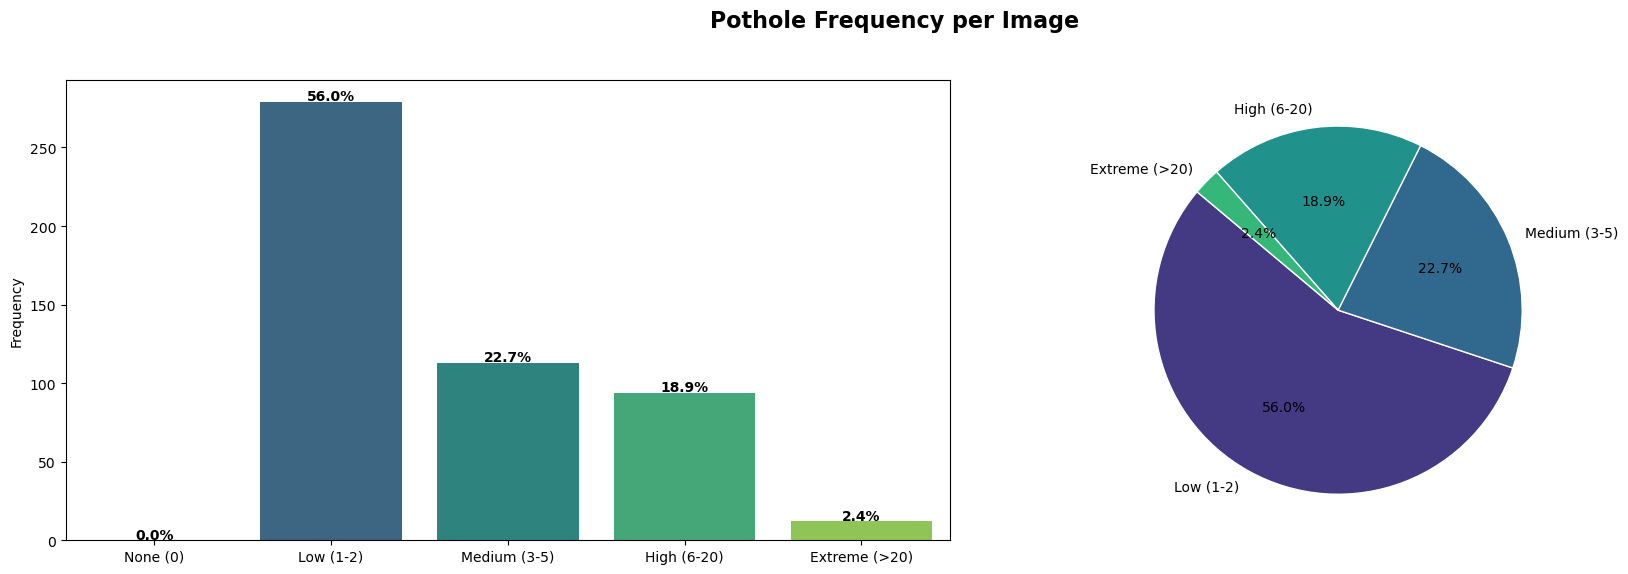

In [18]:
plot_categorical_dist(
    train_subset, 
    col='cat_pothole_count', 
    title='Pothole Frequency per Image', 
    palette='viridis'
)

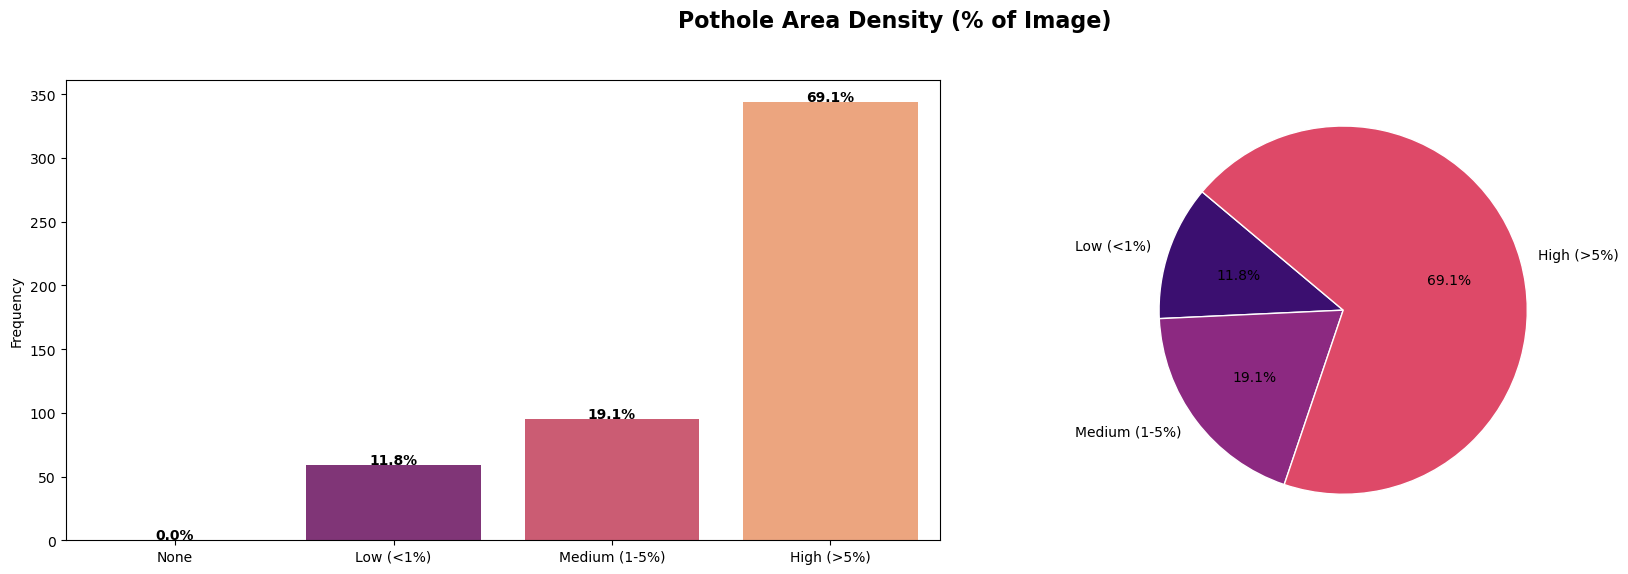

In [19]:
plot_categorical_dist(
    train_subset, 
    col='cat_density', 
    title='Pothole Area Density (% of Image)', 
    palette='magma'
)

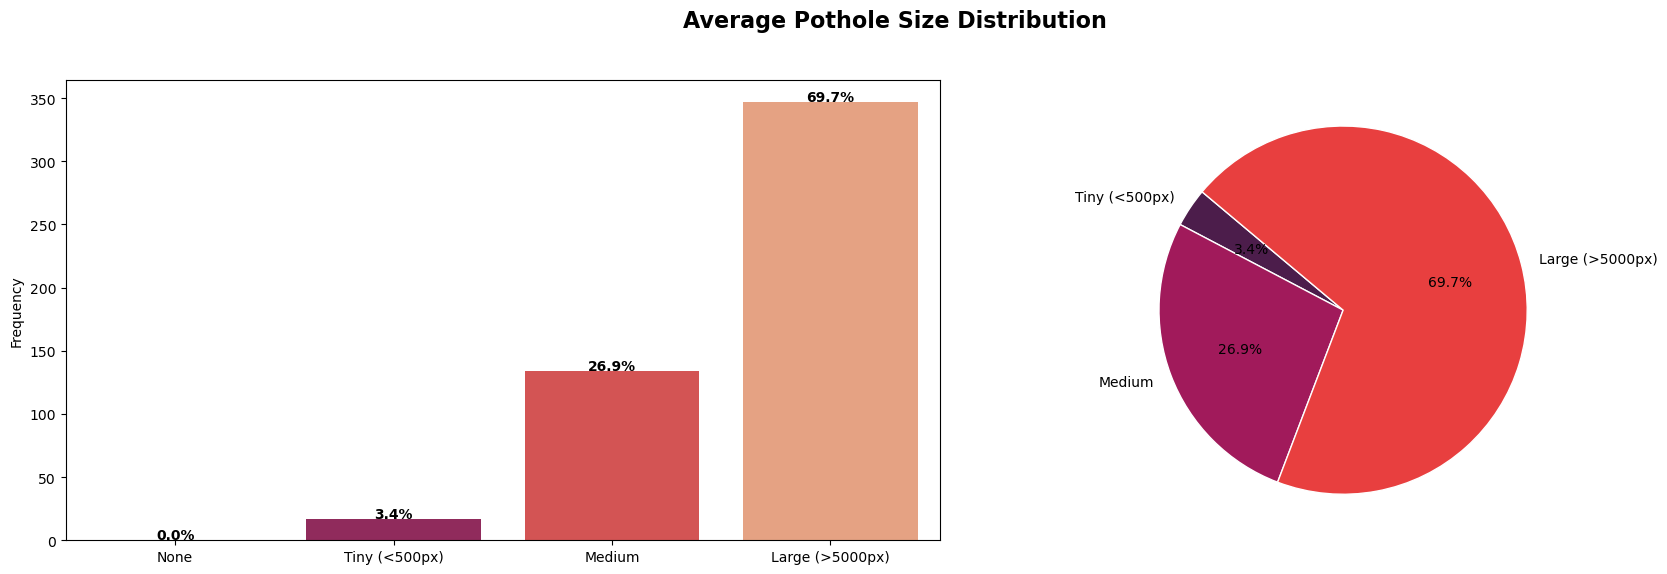

In [20]:
plot_categorical_dist(
    train_subset, 
    col='cat_avg_size', 
    title='Average Pothole Size Distribution', 
    palette='rocket'
)

In [21]:
def plot_position_heatmap(df):
    """Visualizes the spatial distribution of potholes within the camera frame.

    Args:
        df (pd.DataFrame): Dataframe containing 'centroid_x' and 'centroid_y'.
    """
    df_pos = df.dropna(subset=['centroid_x', 'centroid_y'])
    if len(df_pos) == 0: return

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('Pothole Spatial Analysis (Center Bias Check)', fontsize=16, fontweight='bold')

    # Heatmap & Scatter
    sns.kdeplot(data=df_pos, x='centroid_x', y='centroid_y', fill=True, cmap="inferno", 
                alpha=0.6, levels=15, thresh=0.05, ax=axes[0])
    sns.scatterplot(data=df_pos, x='centroid_x', y='centroid_y', s=30, color='cyan', 
                    alpha=0.4, edgecolor='white', ax=axes[0])
    
    axes[0].set_xlim(0, 1); axes[0].set_ylim(1, 0) # Invert Y for image coordinates
    axes[0].set_title("Pothole Center Point Heatmap")
    axes[0].set_xlabel("Horizontal Position (Left <-> Right)")
    axes[0].set_ylabel("Vertical Position (Top <-> Bottom)")

    # Quadrant Distribution
    def categorize_pos(row):
        x, y = row['centroid_x'], row['centroid_y']
        x_lab = 'Center' if 0.33 <= x <= 0.66 else ('Left' if x < 0.33 else 'Right')
        y_lab = 'Center' if 0.33 <= y <= 0.66 else ('Top' if y < 0.33 else 'Bottom')
        if x_lab == 'Center' and y_lab == 'Center': return 'Dead Center'
        if x_lab == 'Center' or y_lab == 'Center': return 'Edge/Middle'
        return 'Corner'

    df_pos = df_pos.copy()
    df_pos['pos_category'] = df_pos.apply(categorize_pos, axis=1)
    counts = df_pos['pos_category'].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[1], palette='viridis')
    axes[1].set_title("Position Category Distribution")
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

A critical Center Bias is also observed in the spatial distribution, where $59.6 \%$ of potholes are located in the center of the frame, leaving the corner regions significantly underrepresented. This strongly suggests a photographic tendency to center the subject, which can lead the model to overfit by prioritizing the center of the image and ignoring peripheral areas in deployment. 

Consequently, heavy geometric **augmentations such as ShiftScaleRotate or RandomCrop** are mandatory to force the model to learn spatial invariance by artificially shifting objects to the image edges.

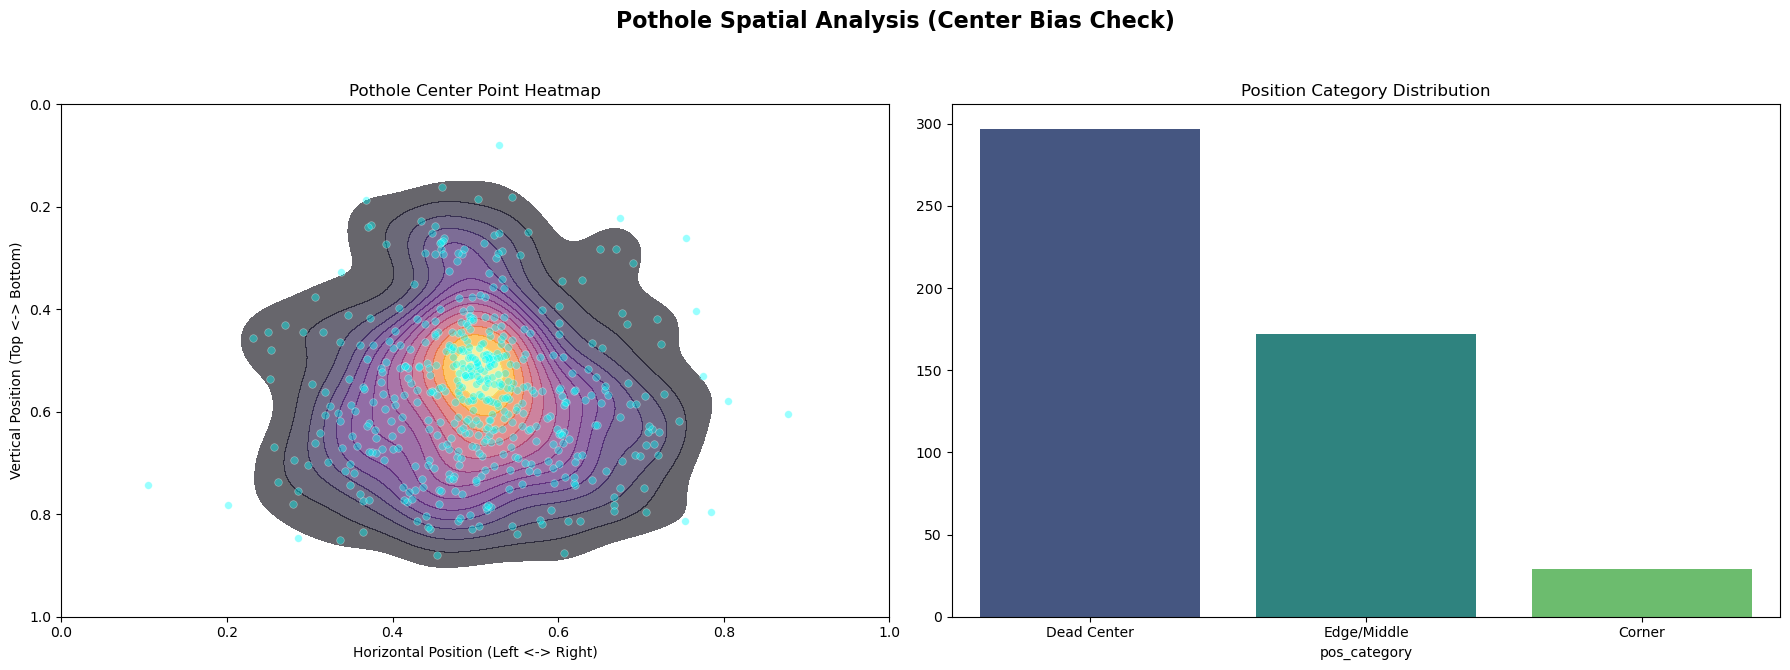

In [22]:
plot_position_heatmap(train_subset)

In [23]:
def plot_dataset_comparison(df, col, title):
    """Plots a grouped horizontal bar chart to compare categories between datasets (e.g., Train vs Test).

    Args:
        df (pd.DataFrame): The combined dataframe containing a 'dataset' column.
        col (str): The categorical column to compare.
        title (str): The title of the plot.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Calculate percentages for meaningful comparison
    counts = df.groupby(['dataset', col]).size().reset_index(name='count')
    totals = df.groupby('dataset').size().reset_index(name='total')
    data = counts.merge(totals, on='dataset')
    data['percentage'] = (data['count'] / data['total']) * 100
    
    # Plotting using the ARA 7.0 theme palette logic
    sns.barplot(data=data, y=col, x='percentage', hue='dataset', ax=ax, palette='coolwarm')
    
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_xlabel('Percentage (%)')
    ax.set_ylabel('')
    ax.set_xlim(0, 100)
    
    # Add bar labels automatically
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

Surprisingly, visual quality analysis reveals an **exceptionally clean dataset, with 88.8% of test images classified as "Very Sharp" and 100% falling within the "Normal" brightness range**, showing no evidence of extreme exposure, darkness, or motion blur. **This high consistency implies that color and quality-degrading augmentations (such as GaussianBlur, MotionBlur, or RandomBrightnessContrast) are unnecessary and potentially harmful**, as they would obscure the high-fidelity asphalt texture features that are crucial for the model to learn.

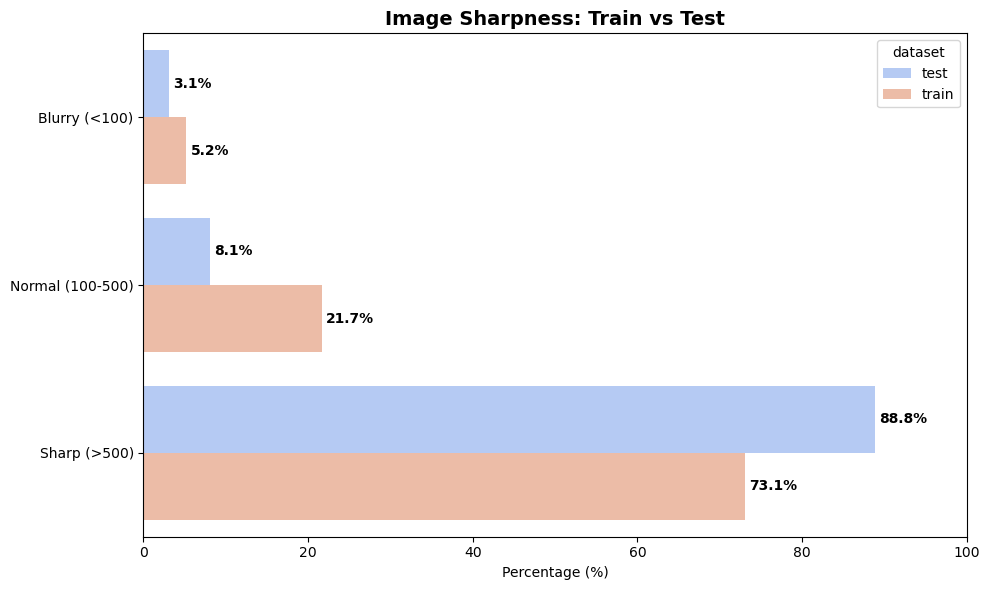

In [24]:
plot_dataset_comparison(
    df_audited, 
    col='cat_blur', 
    title='Image Sharpness: Train vs Test'
)

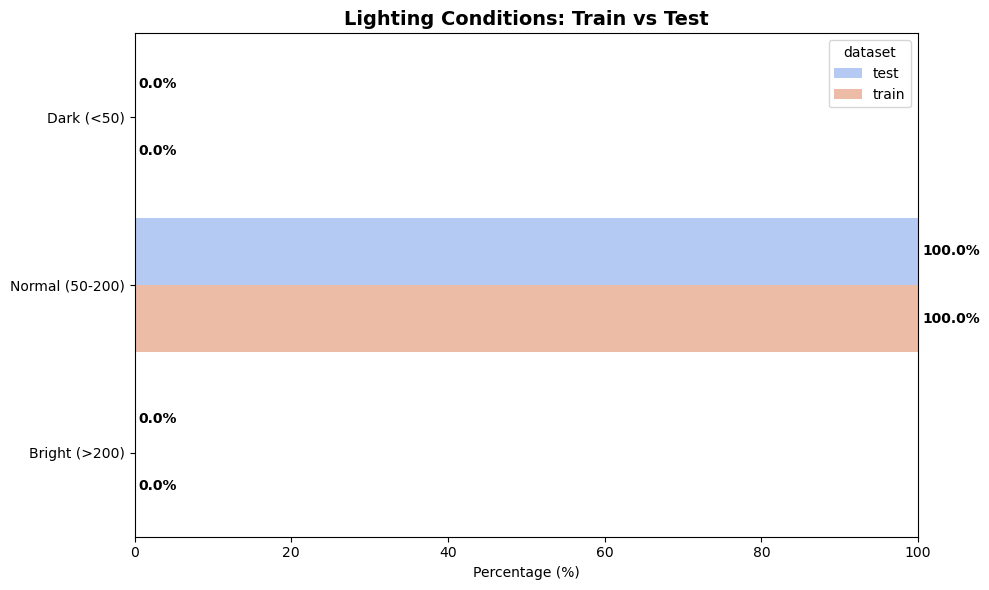

In [25]:
plot_dataset_comparison(
    df_audited, 
    col='cat_brightness', 
    title='Lighting Conditions: Train vs Test'
)

#### Analysis Conclusion

| Dataset Characteristic & Problem | Strategic Action (Preprocessing / Augmentation) |
| :--- | :--- |
| **1. Extreme Scale & Density Imbalance**<br>• 69.7% "Giant" vs 3.4% "Tiny" potholes.<br>• High density (>15% coverage) dominates. | **Stratified Split:** Based on `density` or `area` to ensure tiny samples exist in validation.<br>**Geometric Augmentation:** Aggressive **Zoom Out** (`RandomScale` with negative limits).<br>**Loss Function:** Use **Dice Loss** (superior for large/solid masks) combined with **Binary-Cross Entropy Loss** to avoid Dice Loss' nature of local minima. |
| **2. Severe Center Bias**<br>• 59.6% of objects are located in "Dead Center".<br>• Corner regions are underrepresented. | **Spatial Augmentation:** Heavy **`ShiftScaleRotate`** (high shift limits) or **`RandomCrop`** to force the model to learn spatial invariance (detecting objects at edges). |
| **3. High Visual Consistency**<br>• 100% Normal Brightness.<br>• ~89% Classified as "Very Sharp". | **Disable Intensity Augmentations:** Avoid `GaussianBlur`, `MotionBlur`, or `RandomBrightness` to preserve the **high-fidelity asphalt texture** features already present. |

# Preprocessing & Augmentation

The following cell is the implementation of all augmentations needed to tackle the dataset problems. Notice that every image is resized to $512 \times 512 px$ as the best fit to the model and memory usage.

In [26]:
def get_train_augmentations(image_size, seed=42):
    """
    Strategic Augmentation:
    1. ZOOM OUT: To fix "Giant Pothole" bias.
    2. SHIFT: To fix "Center Bias".
    3. CLEAN: No Blur/Noise because test data is sharp.
    """
    return A.Compose([
        # 1. GEOMETRIC TRANSFOR
        A.ShiftScaleRotate(
            shift_limit=0.2,        
            scale_limit=(-0.5, 0.1),
            rotate_limit=45,        
            border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0,
            p=0.8                  
        ),
        
        A.GridDistortion(
            num_steps=5, 
            distort_limit=0.3, 
            border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0,
            p=0.5                   
        ),

        # 2. STANDARD FLIPS
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),

        # 3. ROBUSTNESS (DROPOUT)
        A.CoarseDropout(
            max_holes=4,
            max_height=int(image_size * 0.1),
            max_width=int(image_size * 0.1),
            min_holes=1, 
            fill_value=0, 
            mask_fill_value=0, 
            p=0.3
        ),

        # 4. RESIZE
        A.Resize(image_size, image_size),
        
    ], seed=seed, is_check_shapes=False) # Seed to ensure reproducibility

def get_valid_augmentations(image_size):
    """Validation: resize only."""
    return A.Compose([
        A.Resize(image_size, image_size),
    ], is_check_shapes=False)

# SEEDED creation
train_aug = get_train_augmentations(CFG.IMAGE_SIZE, seed=CFG.SEED)
valid_aug = get_valid_augmentations(CFG.IMAGE_SIZE)

Here are examples of the augmented train images:

In [27]:
def visualize_augmentations(aug_pipeline, num_samples=3):
    """
    Visualizes the effect of the augmentation pipeline using the robust
    file loading technique from visualize_train_batch.
    """
    # 1. Robust File Search (Sama dengan visualize_train_batch)
    # Mengambil semua file dalam folder tanpa mempedulikan ekstensi spesifik atau subfolder
    all_images = sorted(glob(os.path.join(CFG.TRAIN_IMG_DIR, '*')))
    
    if not all_images:
        print(f"Error: No images found in {CFG.TRAIN_IMG_DIR}. Check your path.")
        return

    # 2. Select Random Sample
    img_path = random.choice(all_images)
    filename = os.path.basename(img_path)
    
    # 3. Find Matching Mask (Teknik ID Matching)
    # Logika: Ambil ID dari nama file gambar (misal: 'train_013' -> '013')
    # Lalu cari mask dengan pola 'mask_013.png'
    try:
        img_id = filename.split('.')[0].split('_')[-1]
        mask_filename = f"mask_{img_id}.png"
        mask_path = os.path.join(CFG.TRAIN_MASK_DIR, mask_filename)
    except IndexError:
        # Fallback jika nama file tidak memiliki underscore
        mask_path = os.path.join(CFG.TRAIN_MASK_DIR, filename)

    # 4. Load Data
    image = cv2.imread(img_path)
    if image is None:
        print(f"Error: Could not load image {img_path}")
        return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Load Mask jika ada
    mask = None
    if os.path.exists(mask_path):
        mask = cv2.imread(mask_path, 0)
    else:
        print(f"Warning: Mask not found at {mask_path}. Visualizing image only.")

    # 5. Visualization Setup
    # Rows: 2 (Image + Mask), Cols: 1 (Original) + num_samples
    rows = 2 if mask is not None else 1
    cols = num_samples + 1
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    
    fig.suptitle(f'Augmentation Audit: {filename}', fontsize=16, fontweight='bold')

    # --- Loop for Original + Augmented Versions ---
    for i in range(cols):
        # A. Prepare Data
        if i == 0:
            # Original Data
            disp_img = image
            disp_mask = mask
            title = "Original Ground Truth"
        else:
            # Apply Augmentation
            # Penting: Kita passing 'mask' agar transformasi geometris sinkron
            if mask is not None:
                data = aug_pipeline(image=image, mask=mask)
                disp_img = data['image']
                disp_mask = data['mask']
            else:
                data = aug_pipeline(image=image)
                disp_img = data['image']
                disp_mask = None
            title = f"Augmented Sample #{i}"

        # B. Plot Image (Top Row)
        ax_img = axes[0, i] if rows > 1 else axes[i]
        ax_img.imshow(disp_img)
        ax_img.set_title(title, fontsize=10, color='darkred' if i==0 else 'teal')
        ax_img.axis('off')

        # C. Plot Mask (Bottom Row) - if exists
        if rows > 1:
            ax_mask = axes[1, i]
            if disp_mask is not None:
                # Menggunakan colormap 'jet' agar perbedaan augmentasi terlihat jelas
                ax_mask.imshow(disp_mask, cmap='jet', interpolation='nearest')
            ax_mask.set_title("Corresponding Mask", fontsize=9)
            ax_mask.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

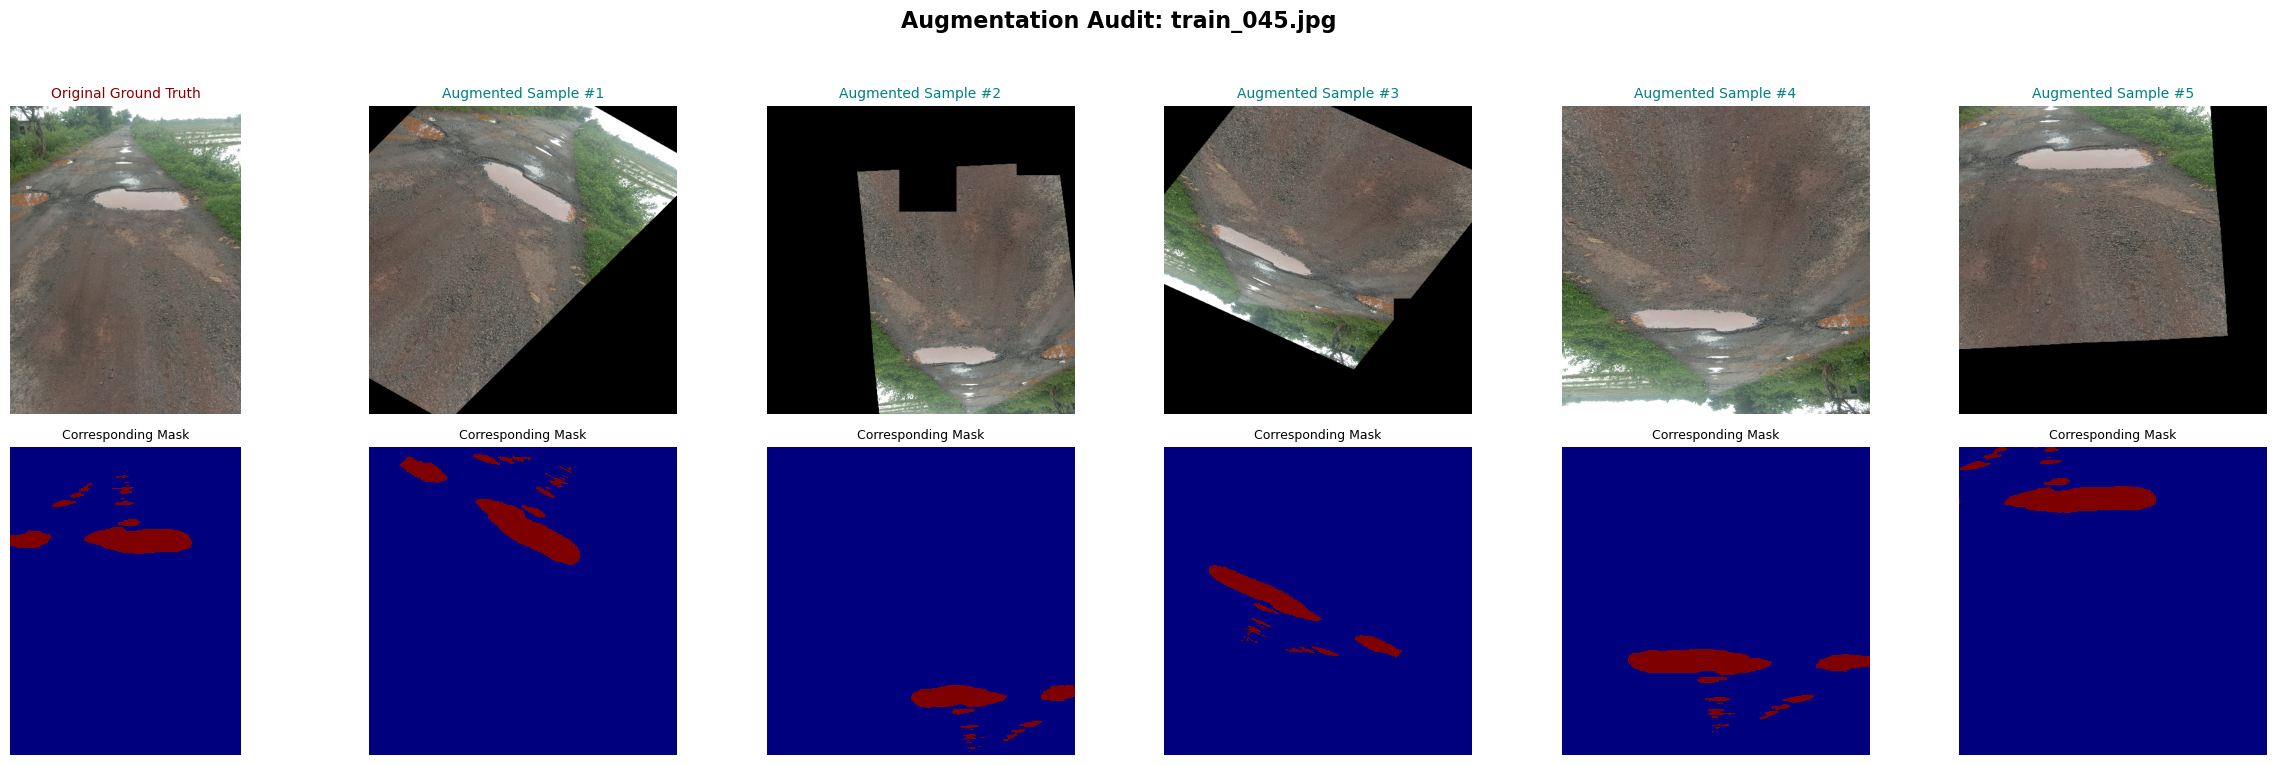

In [28]:
visualize_augmentations(train_aug, 5)

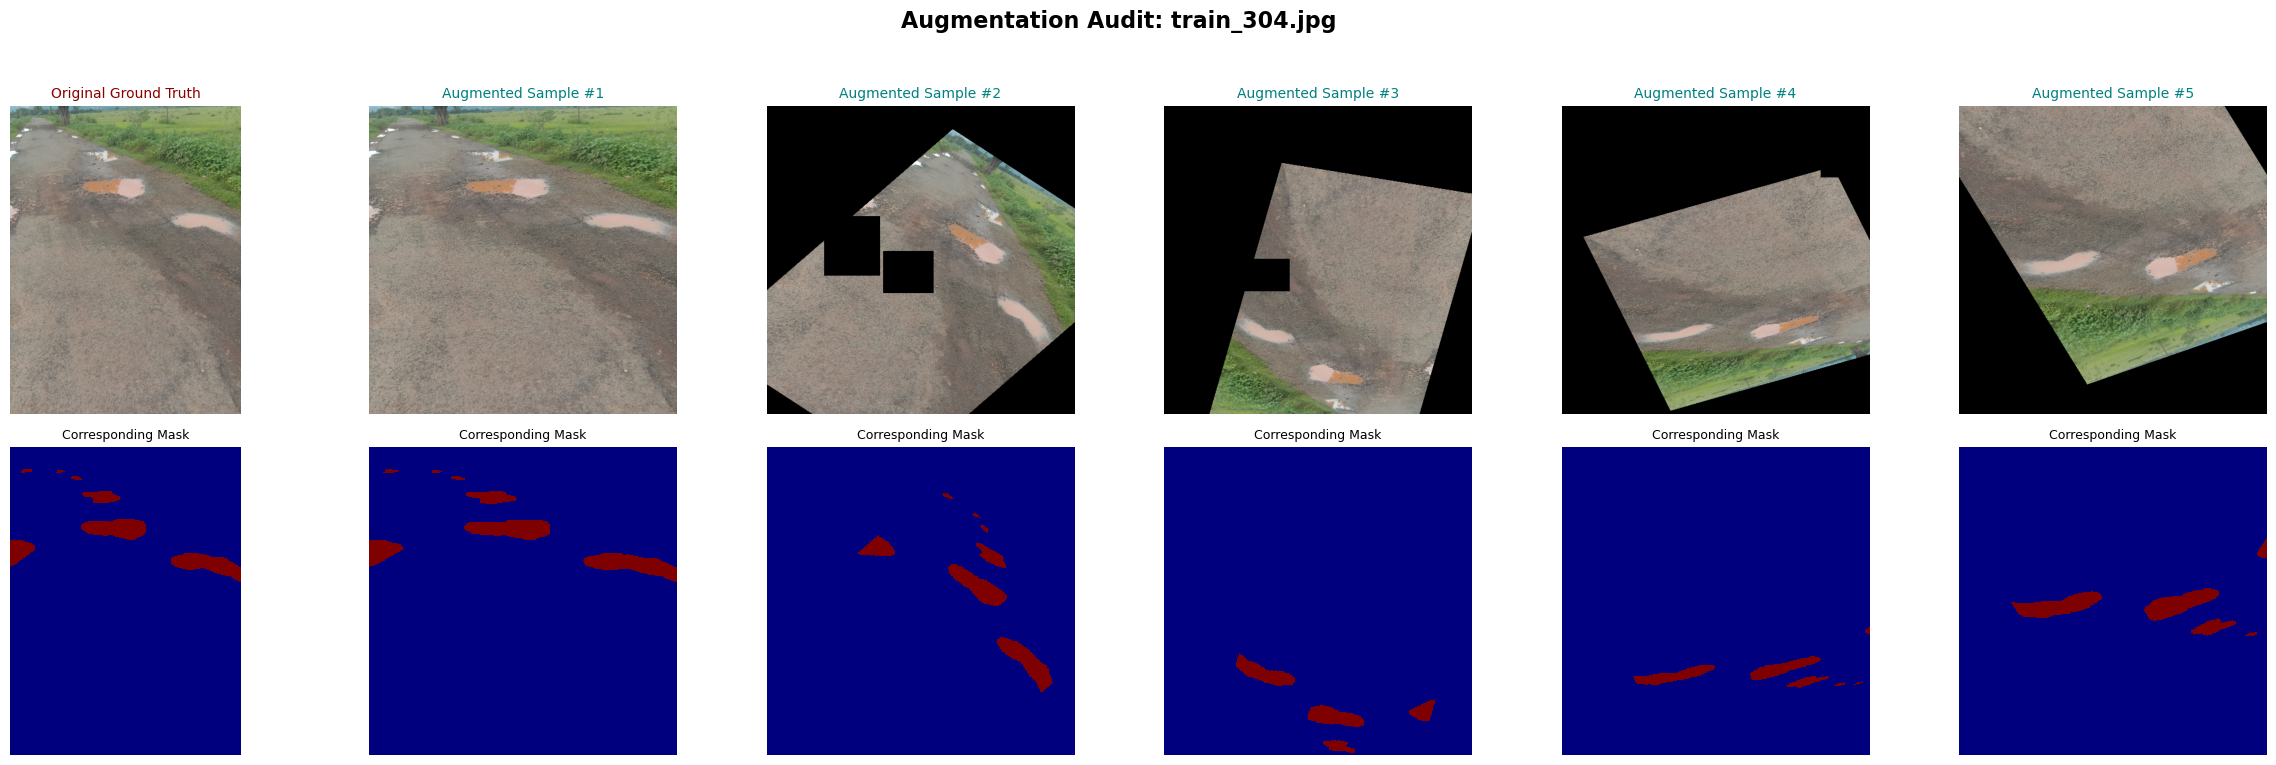

In [29]:
visualize_augmentations(train_aug, 5)

Notice that images are also normalized to ensure faster convergence of model learning and optimization.

In [30]:
# Load HuggingFace Image Processor
processor = AutoImageProcessor.from_pretrained(
    CFG.MODEL_ID,
    do_resize=True,
    size={"height": CFG.IMAGE_SIZE, "width": CFG.IMAGE_SIZE},
    do_pad=False,
    do_normalize=True,
)

print(f"   Mean: {processor.image_mean}  |  Std: {processor.image_std}")
print(f"   Output: {CFG.IMAGE_SIZE}×{CFG.IMAGE_SIZE}  |  Padding: OFF")

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

   Mean: [0.485, 0.456, 0.406]  |  Std: [0.229, 0.224, 0.225]
   Output: 512×512  |  Padding: OFF


The pothole dataset preprocessing below is done in order to achieve learnability with the following EoMT model, discussed in the modeling section

In [31]:
class PotholeDataset(Dataset):
    """
    Pothole segmentation dataset.

    Returns pixel_values (from HF processor) and a binary ground-truth
    mask. We do NOT prepare mask_labels/class_labels for the model's
    internal loss — instead we use a custom Dice+BCE loss on the
    post-processed query outputs.
    """

    def __init__(self, image_paths, mask_paths=None,
                 processor=None, augmentations=None, image_size=512,
                 seed=42):
        self.image_paths   = image_paths
        self.mask_paths    = mask_paths
        self.processor     = processor
        self.augmentations = augmentations
        self.image_size    = image_size
        self.seed          = seed
        self.epoch         = 0

    def set_epoch(self, epoch):
        """Update epoch for reproducible per-epoch augmentations."""
        self.epoch = epoch

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Per-sample seeding
        # Ensures albumentations produces identical transforms
        # for the same (epoch, idx) pair across runs.
        sample_seed = (self.seed + self.epoch * len(self) + idx) % (2**32)
        random.seed(sample_seed)
        np.random.seed(sample_seed)
        torch.manual_seed(sample_seed)

        # Load image as numpy (BGR to RGB)
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.mask_paths is not None:
            # TRAIN / VAL
            mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
            mask = (mask > 127).astype(np.uint8)  # binary 0/1

            # Albumentations (applied on raw numpy — seeded above)
            if self.augmentations:
                aug = self.augmentations(image=image, mask=mask)
                image, mask = aug['image'], aug['mask']

            # HF processor: normalise + tensor
            pil_img = Image.fromarray(image)
            inputs  = self.processor(images=pil_img, return_tensors="pt")
            pixel_values = inputs['pixel_values'].squeeze(0)  # [3, H, W]

            # Ensure mask matches model resolution
            if mask.shape[0] != self.image_size or mask.shape[1] != self.image_size:
                mask = cv2.resize(mask, (self.image_size, self.image_size),
                                  interpolation=cv2.INTER_NEAREST)

            mask_tensor = torch.tensor(mask, dtype=torch.float32)  # [H, W]

            return {
                'pixel_values': pixel_values,
                'mask': mask_tensor,
            }

        else:
            # TEST 
            original_shape = image.shape[:2]
            pil_img = Image.fromarray(image)
            inputs  = self.processor(images=pil_img, return_tensors="pt")
            pixel_values = inputs['pixel_values'].squeeze(0)

            return {
                'pixel_values':  pixel_values,
                'img_path':      self.image_paths[idx],
                'original_size': original_shape,
            }

print("PotholeDataset class defined (custom loss mode — no mask_labels/class_labels)")

PotholeDataset class defined (custom loss mode — no mask_labels/class_labels)


After several experiments, we also found the following stratification, i.e. by density bins with strata of (0-10%, 10-30%, 30-50%, 50%+), is the best split for our model learning process and inference result. An 80/20 split is also chosen as it provides sufficient training data as well as development/validation data.

In [ ]:
# Data Splitting + DataLoaders (STRATIFIED)


# Re-seed to ensure reproducible split regardless of cell execution order
set_seed(CFG.SEED)

# Discover images & masks 
train_image_paths = sorted(glob(os.path.join(CFG.TRAIN_IMG_DIR, '*')))
train_mask_paths  = sorted(glob(os.path.join(CFG.TRAIN_MASK_DIR, '*')))
assert len(train_image_paths) == len(train_mask_paths), "Image/mask count mismatch!"
print(f"Found {len(train_image_paths)} training images + masks")

# Compute mask coverage for stratification
def compute_mask_coverage(mask_path):
    """Compute the percentage of mask pixels that are positive."""
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return 0.0
    return np.mean(mask > 127)

print("Computing mask coverage for stratification...")
mask_coverages = [compute_mask_coverage(mp) for mp in tqdm(train_mask_paths)]

# Bin into strata (0-10%, 10-30%, 30-50%, 50%+)
def coverage_to_stratum(cov):
    if cov < 0.10:
        return 0  # Low coverage
    elif cov < 0.30:
        return 1  # Medium-low
    elif cov < 0.50:
        return 2  # Medium-high
    else:
        return 3  # High coverage

strata = [coverage_to_stratum(c) for c in mask_coverages]
print(f"   Strata distribution: {np.bincount(strata)}")

# Stratified Train / Val split
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    train_image_paths, train_mask_paths,
    test_size=CFG.VALIDATION_SPLIT,
    random_state=CFG.SEED, shuffle=True,
    stratify=strata,
)
print(f"   Train: {len(train_imgs)}  |  Val: {len(val_imgs)}")

# Datasets 
train_dataset = PotholeDataset(
    train_imgs, train_masks, processor, train_aug, CFG.IMAGE_SIZE, seed=CFG.SEED)
valid_dataset = PotholeDataset(
    val_imgs, val_masks, processor, valid_aug, CFG.IMAGE_SIZE, seed=CFG.SEED)

# Collate function 
def collate_fn(batch):
    """Simple collate: stack pixel_values and masks."""
    if 'img_path' in batch[0]:
        return batch  # test set

    pixel_values = torch.stack([b['pixel_values'] for b in batch])  # [B, 3, H, W]
    masks        = torch.stack([b['mask'] for b in batch])          # [B, H, W]

    return {
        'pixel_values': pixel_values,
        'masks':        masks,
    }

# Worker init (reproducibility)
def worker_init_fn(worker_id):
    seed = CFG.SEED + worker_id
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

g_train = torch.Generator()
g_train.manual_seed(CFG.SEED)

g_valid = torch.Generator()
g_valid.manual_seed(CFG.SEED)

# DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=CFG.PIN_MEMORY,
    collate_fn=collate_fn, worker_init_fn=worker_init_fn, generator=g_train,
)
valid_loader = DataLoader(
    valid_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=CFG.PIN_MEMORY,
    collate_fn=collate_fn, worker_init_fn=worker_init_fn, generator=g_valid,
)

print(f"DataLoaders ready  |  Train batches: {len(train_loader)}  |  Val batches: {len(valid_loader)}")

Found 498 training images + masks
Computing mask coverage for stratification...


  0%|          | 0/498 [00:00<?, ?it/s]

   Strata distribution: [261 174  55   8]
   Train: 398  |  Val: 100
DataLoaders ready  |  Train batches: 100  |  Val batches: 25


After running all the previous preprocessing and augmentation setup, we're ready to continue to the modeling phase.

# Modeling Architecture

The **Encoder-only Mask Transformer (EoMT)** represents a streamlined paradigm in image segmentation that eschews traditional architectural complexity by eliminating task-specific modules such as pixel decoders, convolutional adapters, and independent Transformer decoders.  Instead of relying on these external components for feature aggregation, EoMT posits that the necessary inductive biases can be intrinsically learned by a plain Vision Transformer (ViT) through extensive pre-training with Masked Image Modeling (MIM) objectives, such as those utilized in DINOv3. This methodology leverages the high capacity of scaled ViT backbones to extract dense, fine-grained semantic information directly from the encoder, effectively rendering heavy, task-specific architectural add-ons redundant for achieving high-fidelity segmentation.

The specific model selected, *eomt-dinov3-ade-semantic-large-512*, utilizes a ViT-Large backbone and is optimized for semantic segmentation on the ADE20K benchmark with an inference resolution of $512 \times 512$.

In [33]:
# Re-seed before model initialization
set_seed(CFG.SEED)

model = EomtDinov3ForUniversalSegmentation.from_pretrained(CFG.MODEL_ID)

# Re-seed after loading to ensure consistent state
set_seed(CFG.SEED)

model = model.to(CFG.DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"   Total params:     {total_params:,}")
print(f"   Trainable params: {trainable_params:,}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/435 [00:00<?, ?it/s]

   Total params:     314,947,735
   Trainable params: 314,947,735


# Model Training & Validation

In this cell, we define two evaluation metrics for this task:
Dice Coefficient (explained at the beginning) and Intersection over Union (IoU).

Dice Coefficient measures the degree of overlap between the predicted mask and the target mask.
IoU measures the ratio between the overlapping area and the total combined area of prediction and target.

In [34]:
# Compute Dice and IoU metrics
def compute_dice(pred, target, smooth=1e-6):
    p = (pred > 0.5).astype(np.float32)
    t = (target > 0.5).astype(np.float32)
    inter = np.sum(p * t)
    return (2 * inter + smooth) / (np.sum(p) + np.sum(t) + smooth)

def compute_iou(pred, target, smooth=1e-6):
    p = (pred > 0.5).astype(np.float32)
    t = (target > 0.5).astype(np.float32)
    inter = np.sum(p * t)
    union = np.sum(p) + np.sum(t) - inter
    return (inter + smooth) / (union + smooth)

After several experiments, we have found that using a combination of Dice Loss and Binary Cross-Entropy (BCE) Loss works well for segmentation tasks like pothole detection. Dice Loss helps to maximize the overlap between predicted masks and the ground truth masks, while BCE Loss penalizes pixel-wise classification errors.

In [35]:
optimizer = torch.optim.AdamW(
    model.parameters(), lr=CFG.LEARNING_RATE, weight_decay=0.01)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG.EPOCHS, eta_min=1e-7)

history = {
    'train_loss': [], 'val_loss': [],
    'val_dice':   [], 'learning_rates': [],
}

# Combined Dice Loss + Binary Cross-Entropy Loss
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        # pred: [B, H, W] in [0, 1]  |  target: [B, H, W] in {0, 1}
        pred_flat   = pred.contiguous().view(-1)
        target_flat = target.contiguous().view(-1)

        # Dice Loss
        intersection = (pred_flat * target_flat).sum()
        dice = (2 * intersection + self.smooth) / (
            pred_flat.sum() + target_flat.sum() + self.smooth)
        dice_loss = 1 - dice

        # BCE Loss
        bce_loss = F.binary_cross_entropy(
            pred_flat.clamp(1e-7, 1 - 1e-7), target_flat)

        return 0.5 * dice_loss + 0.5 * bce_loss


criterion = DiceBCELoss()

# Query Mask Combination
def combine_query_masks(outputs, target_size):
    """
    Differentiable combination of EoMT query predictions into a
    single binary-segmentation probability map.

    Strategy: weight each query's mask by its "objectness"
    (1 − P(no_object)), where the last class dim is the no-object
    class (standard in Mask2Former-style models).

    Returns: [B, H, W] tensor on the same device, gradients preserved.
    """
    masks_logits = outputs.masks_queries_logits  # [B, Q, h, w]
    class_logits = outputs.class_queries_logits  # [B, Q, C]

    B, Q, h, w = masks_logits.shape

    # Upsample mask logits to target resolution if needed
    if (h, w) != (target_size, target_size):
        masks_logits = F.interpolate(
            masks_logits.flatten(0, 1).unsqueeze(1),         # [B*Q, 1, h, w]
            size=(target_size, target_size),
            mode='bilinear', align_corners=False,
        ).squeeze(1).view(B, Q, target_size, target_size)

    pred_masks  = torch.sigmoid(masks_logits)                # [B, Q, H, W]
    class_probs = torch.softmax(class_logits, dim=-1)        # [B, Q, C]

    # Last class = "no object" → objectness = 1 − P(no_object)
    obj_weight = 1.0 - class_probs[:, :, -1]                 # [B, Q]

    # Weighted average of query masks
    combined = (pred_masks * obj_weight.unsqueeze(-1).unsqueeze(-1)).sum(dim=1)
    combined = combined / (obj_weight.sum(dim=1, keepdim=True).unsqueeze(-1) + 1e-6)
    combined = combined.clamp(0, 1)

    return combined  # [B, H, W]

def extract_pred_mask_np(outputs, batch_idx=0, target_size=512):
    """Non-differentiable version for evaluation / inference (returns numpy)."""
    masks_logits = outputs.masks_queries_logits[batch_idx]   # [Q, h, w]
    class_logits = outputs.class_queries_logits[batch_idx]   # [Q, C]

    Q, h, w = masks_logits.shape
    if (h, w) != (target_size, target_size):
        masks_logits = F.interpolate(
            masks_logits.unsqueeze(1),
            size=(target_size, target_size),
            mode='bilinear', align_corners=False,
        ).squeeze(1)

    pred_masks  = torch.sigmoid(masks_logits)
    class_probs = torch.softmax(class_logits, dim=-1)
    obj_weight  = 1.0 - class_probs[:, -1]

    combined = (pred_masks * obj_weight.view(-1, 1, 1)).sum(0)
    combined = combined / (obj_weight.sum() + 1e-6)
    return combined.clamp(0, 1).cpu().numpy()

### Training Loop

After initializing the loss function, we now proceed to the training and validation phase of the model. The training loop implements the following steps for each epoch:
1. Feeding the preprocessed images into the model.
2. Calculating the combined loss.
3. Updating the model weights using backpropagation.

Early stopping and model checkpointing are employed to prevent overfitting and retain the best-performing model based on validation Dice Coefficient.

In [36]:

# Re-seed to ensure a reproducible training phase
set_seed(CFG.SEED)
train_loader.generator.manual_seed(CFG.SEED)
valid_loader.generator.manual_seed(CFG.SEED)

best_dice = 0.0
patience_counter = 0
EARLY_STOP_PATIENCE = 5

rng_state = torch.get_rng_state()
cuda_rng_state = torch.cuda.get_rng_state() if torch.cuda.is_available() else None
np_rng_state = np.random.get_state()
py_rng_state = random.getstate()

model.eval()
with torch.no_grad():
    diag_batch = next(iter(train_loader))
    diag_pv    = diag_batch['pixel_values'].to(CFG.DEVICE)
    diag_out   = model(pixel_values=diag_pv)
    diag_pred  = combine_query_masks(diag_out, CFG.IMAGE_SIZE)
    diag_loss  = criterion(diag_pred, diag_batch['masks'].to(CFG.DEVICE))
    print(f"   masks_queries_logits : {diag_out.masks_queries_logits.shape}")
    print(f"   class_queries_logits : {diag_out.class_queries_logits.shape}")
    print(f"   combined pred range  : [{diag_pred.min():.4f}, {diag_pred.max():.4f}]")
    print(f"   diagnostic loss      : {diag_loss.item():.4f}")
    assert not torch.isnan(diag_loss), "NaN loss detected"

torch.set_rng_state(rng_state)
if cuda_rng_state is not None:
    torch.cuda.set_rng_state(cuda_rng_state)
np.random.set_state(np_rng_state)
random.setstate(py_rng_state)

set_seed(CFG.SEED)
train_loader.generator.manual_seed(CFG.SEED)
valid_loader.generator.manual_seed(CFG.SEED)

# Main Loop
for epoch in range(CFG.EPOCHS):
    train_loader.generator.manual_seed(CFG.SEED + epoch)
    valid_loader.generator.manual_seed(CFG.SEED + epoch)
    
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{CFG.EPOCHS}  |  LR: {optimizer.param_groups[0]['lr']:.2e}")
    print(f"{'='*60}")

    # Model Training
    model.train()
    running_loss = 0.0

    for batch in tqdm(train_loader, desc='Train', leave=False):
        pixel_values = batch['pixel_values'].to(CFG.DEVICE)
        masks        = batch['masks'].to(CFG.DEVICE)

        optimizer.zero_grad()

        outputs = model(pixel_values=pixel_values)
        pred    = combine_query_masks(outputs, CFG.IMAGE_SIZE)
        loss    = criterion(pred, masks)

        if torch.isnan(loss):
            print("NaN loss — skipping batch")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / max(len(train_loader), 1)

    # Model Validation
    model.eval()
    val_running_loss = 0.0
    val_preds, val_targets = [], []

    with torch.no_grad():
        for batch in tqdm(valid_loader, desc='Val', leave=False):
            pixel_values = batch['pixel_values'].to(CFG.DEVICE)
            masks        = batch['masks'].to(CFG.DEVICE)

            outputs = model(pixel_values=pixel_values)
            pred    = combine_query_masks(outputs, CFG.IMAGE_SIZE)
            loss    = criterion(pred, masks)
            val_running_loss += loss.item()

            for i in range(pred.shape[0]):
                pred_bin   = (pred[i].cpu().numpy() > 0.5).astype(np.uint8)
                target_bin = masks[i].cpu().numpy().astype(np.uint8)
                val_preds.append(pred_bin.flatten())
                val_targets.append(target_bin.flatten())

    val_loss = val_running_loss / max(len(valid_loader), 1)
    val_dice = compute_dice(
        np.concatenate(val_preds), np.concatenate(val_targets)
    ) if val_preds else 0.0

    # Logging
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['learning_rates'].append(optimizer.param_groups[0]['lr'])

    print(f"Train Loss: {train_loss:.4f}  |  Val Loss: {val_loss:.4f}  |  Val Dice: {val_dice:.4f}")

    # Checkpoint saving & Early Stopping
    if val_dice > best_dice:
        best_dice = val_dice
        patience_counter = 0
        torch.cuda.empty_cache()
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_dice': best_dice,
            'history': history,
            'rng_state': torch.get_rng_state(),
            'cuda_rng_state': torch.cuda.get_rng_state() if torch.cuda.is_available() else None,
        }, CFG.MODEL_SAVE_PATH)
        print(f"Saved! Best Dice: {best_dice:.4f}")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{EARLY_STOP_PATIENCE})")
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    scheduler.step()

print(f"\nTraining complete! Best Dice: {best_dice:.4f}")

   masks_queries_logits : torch.Size([4, 100, 128, 128])
   class_queries_logits : torch.Size([4, 100, 151])
   combined pred range  : [0.0000, 0.5605]
   diagnostic loss      : 0.5369

Epoch 1/12  |  LR: 1.00e-05


Train:   0%|          | 0/100 [00:00<?, ?it/s]

Val:   0%|          | 0/25 [00:00<?, ?it/s]

Train Loss: 0.3435  |  Val Loss: 0.2032  |  Val Dice: 0.8279
Saved! Best Dice: 0.8279

Epoch 2/12  |  LR: 9.83e-06


Train:   0%|          | 0/100 [00:00<?, ?it/s]

...

Val:   0%|          | 0/25 [00:00<?, ?it/s]

Train Loss: 0.0951  |  Val Loss: 0.1464  |  Val Dice: 0.8678
No improvement (4/5)

Epoch 11/12  |  LR: 7.63e-07


Train:   0%|          | 0/100 [00:00<?, ?it/s]

Val:   0%|          | 0/25 [00:00<?, ?it/s]

Train Loss: 0.0923  |  Val Loss: 0.1463  |  Val Dice: 0.8690
No improvement (5/5)

Early stopping at epoch 11

Training complete! Best Dice: 0.8693


We then plot the training historic data to analyze the model performance and training dynamics over epochs. This visualization helps in identifying trends such as convergence, overfitting, or underfitting.

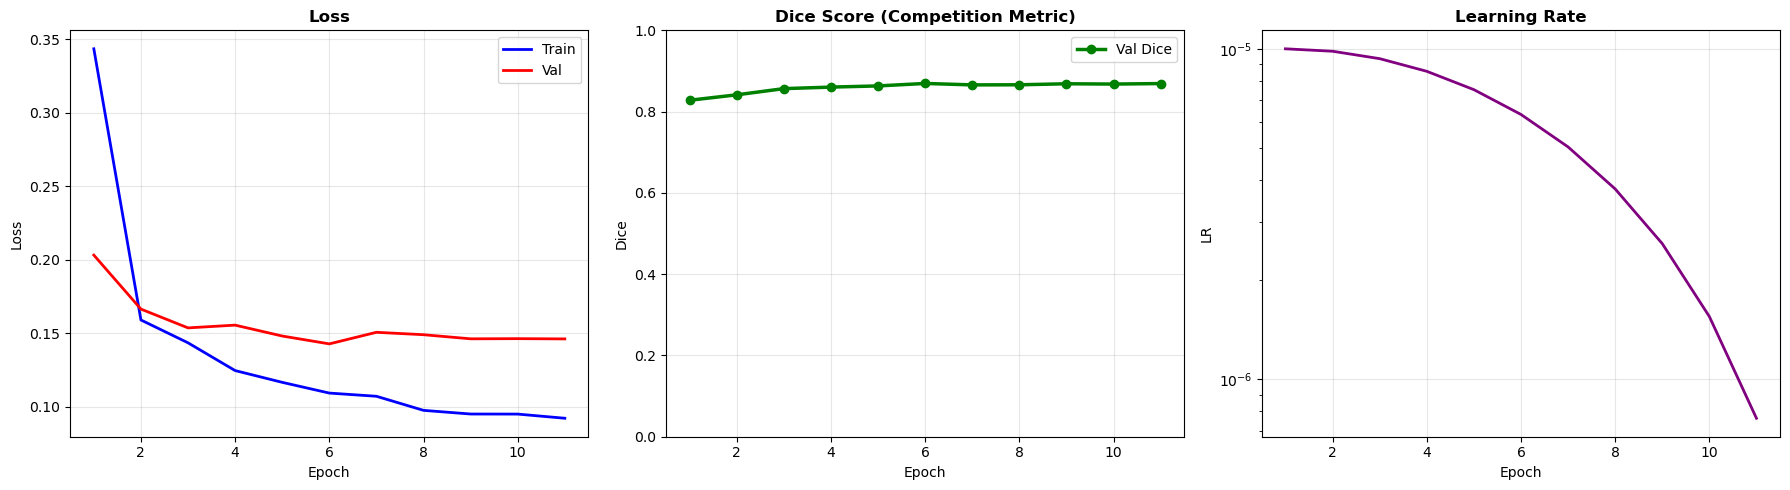


Best Val Dice: 0.8693  |  Best Val Loss: 0.1429


In [37]:
def plot_history(hist):
    """Plots training history: loss, dice, learning rate."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(hist['train_loss']) + 1)

    # Loss
    axes[0].plot(epochs, hist['train_loss'], 'b-', lw=2, label='Train')
    axes[0].plot(epochs, hist['val_loss'],   'r-', lw=2, label='Val')
    axes[0].set_title('Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Dice
    axes[1].plot(epochs, hist['val_dice'], 'g-', lw=2.5, marker='o', label='Val Dice')
    axes[1].set_title('Dice Score (Competition Metric)', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice')
    axes[1].legend(); axes[1].grid(True, alpha=0.3); axes[1].set_ylim([0, 1])

    # LR
    axes[2].plot(epochs, hist['learning_rates'], 'purple', lw=2)
    axes[2].set_title('Learning Rate', fontweight='bold')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
    axes[2].set_yscale('log'); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
    plt.show()

    print(f"\nBest Val Dice: {max(hist['val_dice']):.4f}  |  "
          f"Best Val Loss: {min(hist['val_loss']):.4f}")

plot_history(history)

## Model Loading

Skip training by setting `CFG.PRETRAINED_MODEL_PATH` to the model checkpoint path, the model can be downloaded here: https://bit.ly/ARA_DSC_Tim_ARB

In [ ]:
# Option 1: Load from CFG.PRETRAINED_MODEL_PATH if set
# Option 2: Specify a custom path here
# CUSTOM_MODEL_PATH = 'path/to/your/model.pth'

model_path = CFG.PRETRAINED_MODEL_PATH 

if model_path and os.path.exists(model_path):
    print(f"Loading pre-trained model from: {model_path}")
    inference_model = EomtDinov3ForUniversalSegmentation.from_pretrained(CFG.MODEL_ID)
    checkpoint = torch.load(model_path, map_location=CFG.DEVICE, weights_only=False)
    inference_model.load_state_dict(checkpoint['model_state_dict'])
    inference_model = inference_model.to(CFG.DEVICE)
    inference_model.eval()
    print(f" Model loaded!")
    print(f"  - Epoch: {checkpoint.get('epoch', 'N/A')}")
    print(f"  - Best Dice: {checkpoint.get('best_dice', 'N/A'):.4f}")
    SKIP_TRAINING = True
else:
    print("No pre-trained model path specified or file not found.")
    SKIP_TRAINING = False

# Inference & Post-processing

### Util: Encode Run-Length Encoding (RLE)

In [38]:
def encode_rle(mask: np.ndarray, pos_value: int = 255) -> str:
    """Encode binary mask into Run-Length Encoding string."""
    binary = (mask == pos_value).astype(np.uint8)
    pixels = binary.T.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[0::2]
    return " ".join(str(x) for x in runs)

# Quick sanity check
_test = np.zeros((5, 5), dtype=np.uint8)
_test[1:3, 1:3] = 255
print(f"RLE encoder ready  |  Test: '{encode_rle(_test)}'")
del _test

RLE encoder ready  |  Test: '7 2 12 2'


Model inference is done on test set images, which are preprocessed in the same way as the training images. The model will output predicted masks for each test image, which will then be post-processed to generate the final submission.

In [39]:
# Free training model memory
del model
torch.cuda.empty_cache()
gc.collect()

# Re-seed for reproducible inference
set_seed(CFG.SEED)

inference_model = EomtDinov3ForUniversalSegmentation.from_pretrained(CFG.MODEL_ID)
checkpoint = torch.load(CFG.MODEL_SAVE_PATH, map_location=CFG.DEVICE, weights_only=False)
inference_model.load_state_dict(checkpoint['model_state_dict'])
inference_model = inference_model.to(CFG.DEVICE)
inference_model.eval()

print(f"Best model loaded (epoch {checkpoint['epoch']})  |  Dice: {checkpoint['best_dice']:.4f}")

Loading weights:   0%|          | 0/435 [00:00<?, ?it/s]

Best model loaded (epoch 6)  |  Dice: 0.8693


### Test-Time Augmentation (TTA)

Test-Time Augmentation (TTA) is employed as a post-training inference strategy to enhance model robustness and prediction stability. Instead of relying on a single forward pass, the model generates predictions for multiple augmented versions of the same input image. These predictions are then aggregated to smooth out stochastic errors, reduce variance, and capture features that might be missed in a single orientation.

---

### Strategy
We utilize a conservative TTA approach, such that we only apply geometric transformations that are strictly reversible and do not alter the semantic content of the image. Specifically, the strategy involves three variations:

Original Image: The standard input.

Horizontal Flip: The image mirrored left-to-right.

Vertical Flip: The image mirrored top-to-bottom.

---

For each variant, the model predicts a probability mask. The flipped predictions are then geometrically inverted (flipped back) to align with the original orientation. Finally, all three probability maps are averaged to produce a consensus prediction. This averaging process acts as an ensemble method, filtering out noise and reinforcing high-confidence regions.

---


In [40]:
import torch.nn.functional as F

def infer_with_tta_safe(model, image_pil, processor, device=CFG.DEVICE):
    """
    Safe TTA Strategy (Flip-based) resulting in 4 predictions averaged:
    1. Original
    2. Horizontal Flip
    3. Vertical Flip
    """
    # Prepare input
    inputs = processor(images=image_pil, return_tensors="pt")
    pixel_values = inputs['pixel_values'].to(device) # [1, 3, H, W]
    
    total_pred = None
    count = 0
    
    # --- 1. Original ---
    with torch.inference_mode():
        outputs = model(pixel_values=pixel_values)
        pred_prob = combine_query_masks_tensor(outputs, pixel_values.shape[-1]) # Custom helper needed below
        total_pred = pred_prob
        count += 1

    # --- 2. Horizontal Flip ---
    pv_hflip = torch.flip(pixel_values, dims=[3]) 
    with torch.inference_mode():
        outputs = model(pixel_values=pv_hflip)
        pred_hflip = combine_query_masks_tensor(outputs, pixel_values.shape[-1])
        pred_back = torch.flip(pred_hflip, dims=[3])
        total_pred += pred_back
        count += 1
        
    # --- 3. Vertical Flip ---
    pv_vflip = torch.flip(pixel_values, dims=[2])
    with torch.inference_mode():
        outputs = model(pixel_values=pv_vflip)
        pred_vflip = combine_query_masks_tensor(outputs, pixel_values.shape[-1])
        pred_back = torch.flip(pred_vflip, dims=[2])
        total_pred += pred_back
        count += 1
        
    # --- Average ---
    final_pred = total_pred / count
    return final_pred.squeeze().cpu().numpy() # Return numpy [H, W]

def combine_query_masks_tensor(outputs, target_size):
    """Helper to combine query masks into a single mask tensor."""
    masks_logits = outputs.masks_queries_logits
    class_logits = outputs.class_queries_logits
    
    B, Q, h, w = masks_logits.shape
    
    # Interpolating to target size
    masks_logits = F.interpolate(
        masks_logits, 
        size=(target_size, target_size), 
        mode='bilinear', align_corners=False
    )
    
    pred_masks  = torch.sigmoid(masks_logits)
    class_probs = torch.softmax(class_logits, dim=-1)
    obj_weight  = 1.0 - class_probs[:, :, -1]
    
    # Weighted average
    combined = (pred_masks * obj_weight.unsqueeze(-1).unsqueeze(-1)).sum(dim=1)
    combined = combined / (obj_weight.sum(dim=1, keepdim=True).unsqueeze(-1) + 1e-6)
    
    return combined # Output: [B, 1, H, W] or [B, H, W]
    
def combine_query_masks_tensor(outputs, target_size):
    """Updated helper to combine query masks into a single mask tensor."""
    masks_logits = outputs.masks_queries_logits
    class_logits = outputs.class_queries_logits
    
    # Upsample
    masks_logits = F.interpolate(
        masks_logits, size=(target_size, target_size), 
        mode='bilinear', align_corners=False
    ) # [B, Q, H, W]
    
    pred_masks  = torch.sigmoid(masks_logits)
    class_probs = torch.softmax(class_logits, dim=-1) # [B, Q, C]
    obj_weight  = 1.0 - class_probs[:, :, -1] # [B, Q]
    
    # Weighting: [B, Q, H, W] * [B, Q, 1, 1] -> Sum dim 1
    weighted_masks = pred_masks * obj_weight.view(masks_logits.shape[0], masks_logits.shape[1], 1, 1)
    combined = weighted_masks.sum(dim=1, keepdim=True) # [B, 1, H, W]
    norm = obj_weight.sum(dim=1, keepdim=True).view(masks_logits.shape[0], 1, 1, 1) + 1e-6
    
    return combined / norm

# Main TTA Inference Loop
test_image_paths = sorted(glob(os.path.join(CFG.TEST_IMG_DIR, '*')))
tta_submission_results = []

inference_model.eval()

print(f"Running Safe TTA (Original + HFlip + VFlip)...")

for img_path in tqdm(test_image_paths, desc='TTA Predicting'):
    image = Image.open(img_path).convert('RGB')
    original_size = np.array(image).shape[:2] # (H, W)
    
    # Run TTA inference with 3 flips
    tta_pred = infer_with_tta_safe(inference_model, image, processor)
    
    # Resizing back to original size
    tta_pred = cv2.resize(tta_pred, (original_size[1], original_size[0]))
    
    binary_mask = (tta_pred > 0.5).astype(np.uint8) * 255
    tta_submission_results.append({
        'ImageId': os.path.basename(img_path),
        'rle': encode_rle(binary_mask)
    })

print(f"TTA Done.")

Running Safe TTA (Original + HFlip + VFlip)...


TTA Predicting:   0%|          | 0/295 [00:00<?, ?it/s]

TTA Done.


## Post Processing & Evaluation

The model's performance is evaluated through visual inspection of the validation set, specifically by overlaying predicted segmentation masks against ground truth data. This qualitative analysis identifies specific failure modes and strengths, to evaluate robustness across varying pothole appearances and road surface conditions.

Analyzing Val:   0%|          | 0/25 [00:00<?, ?it/s]

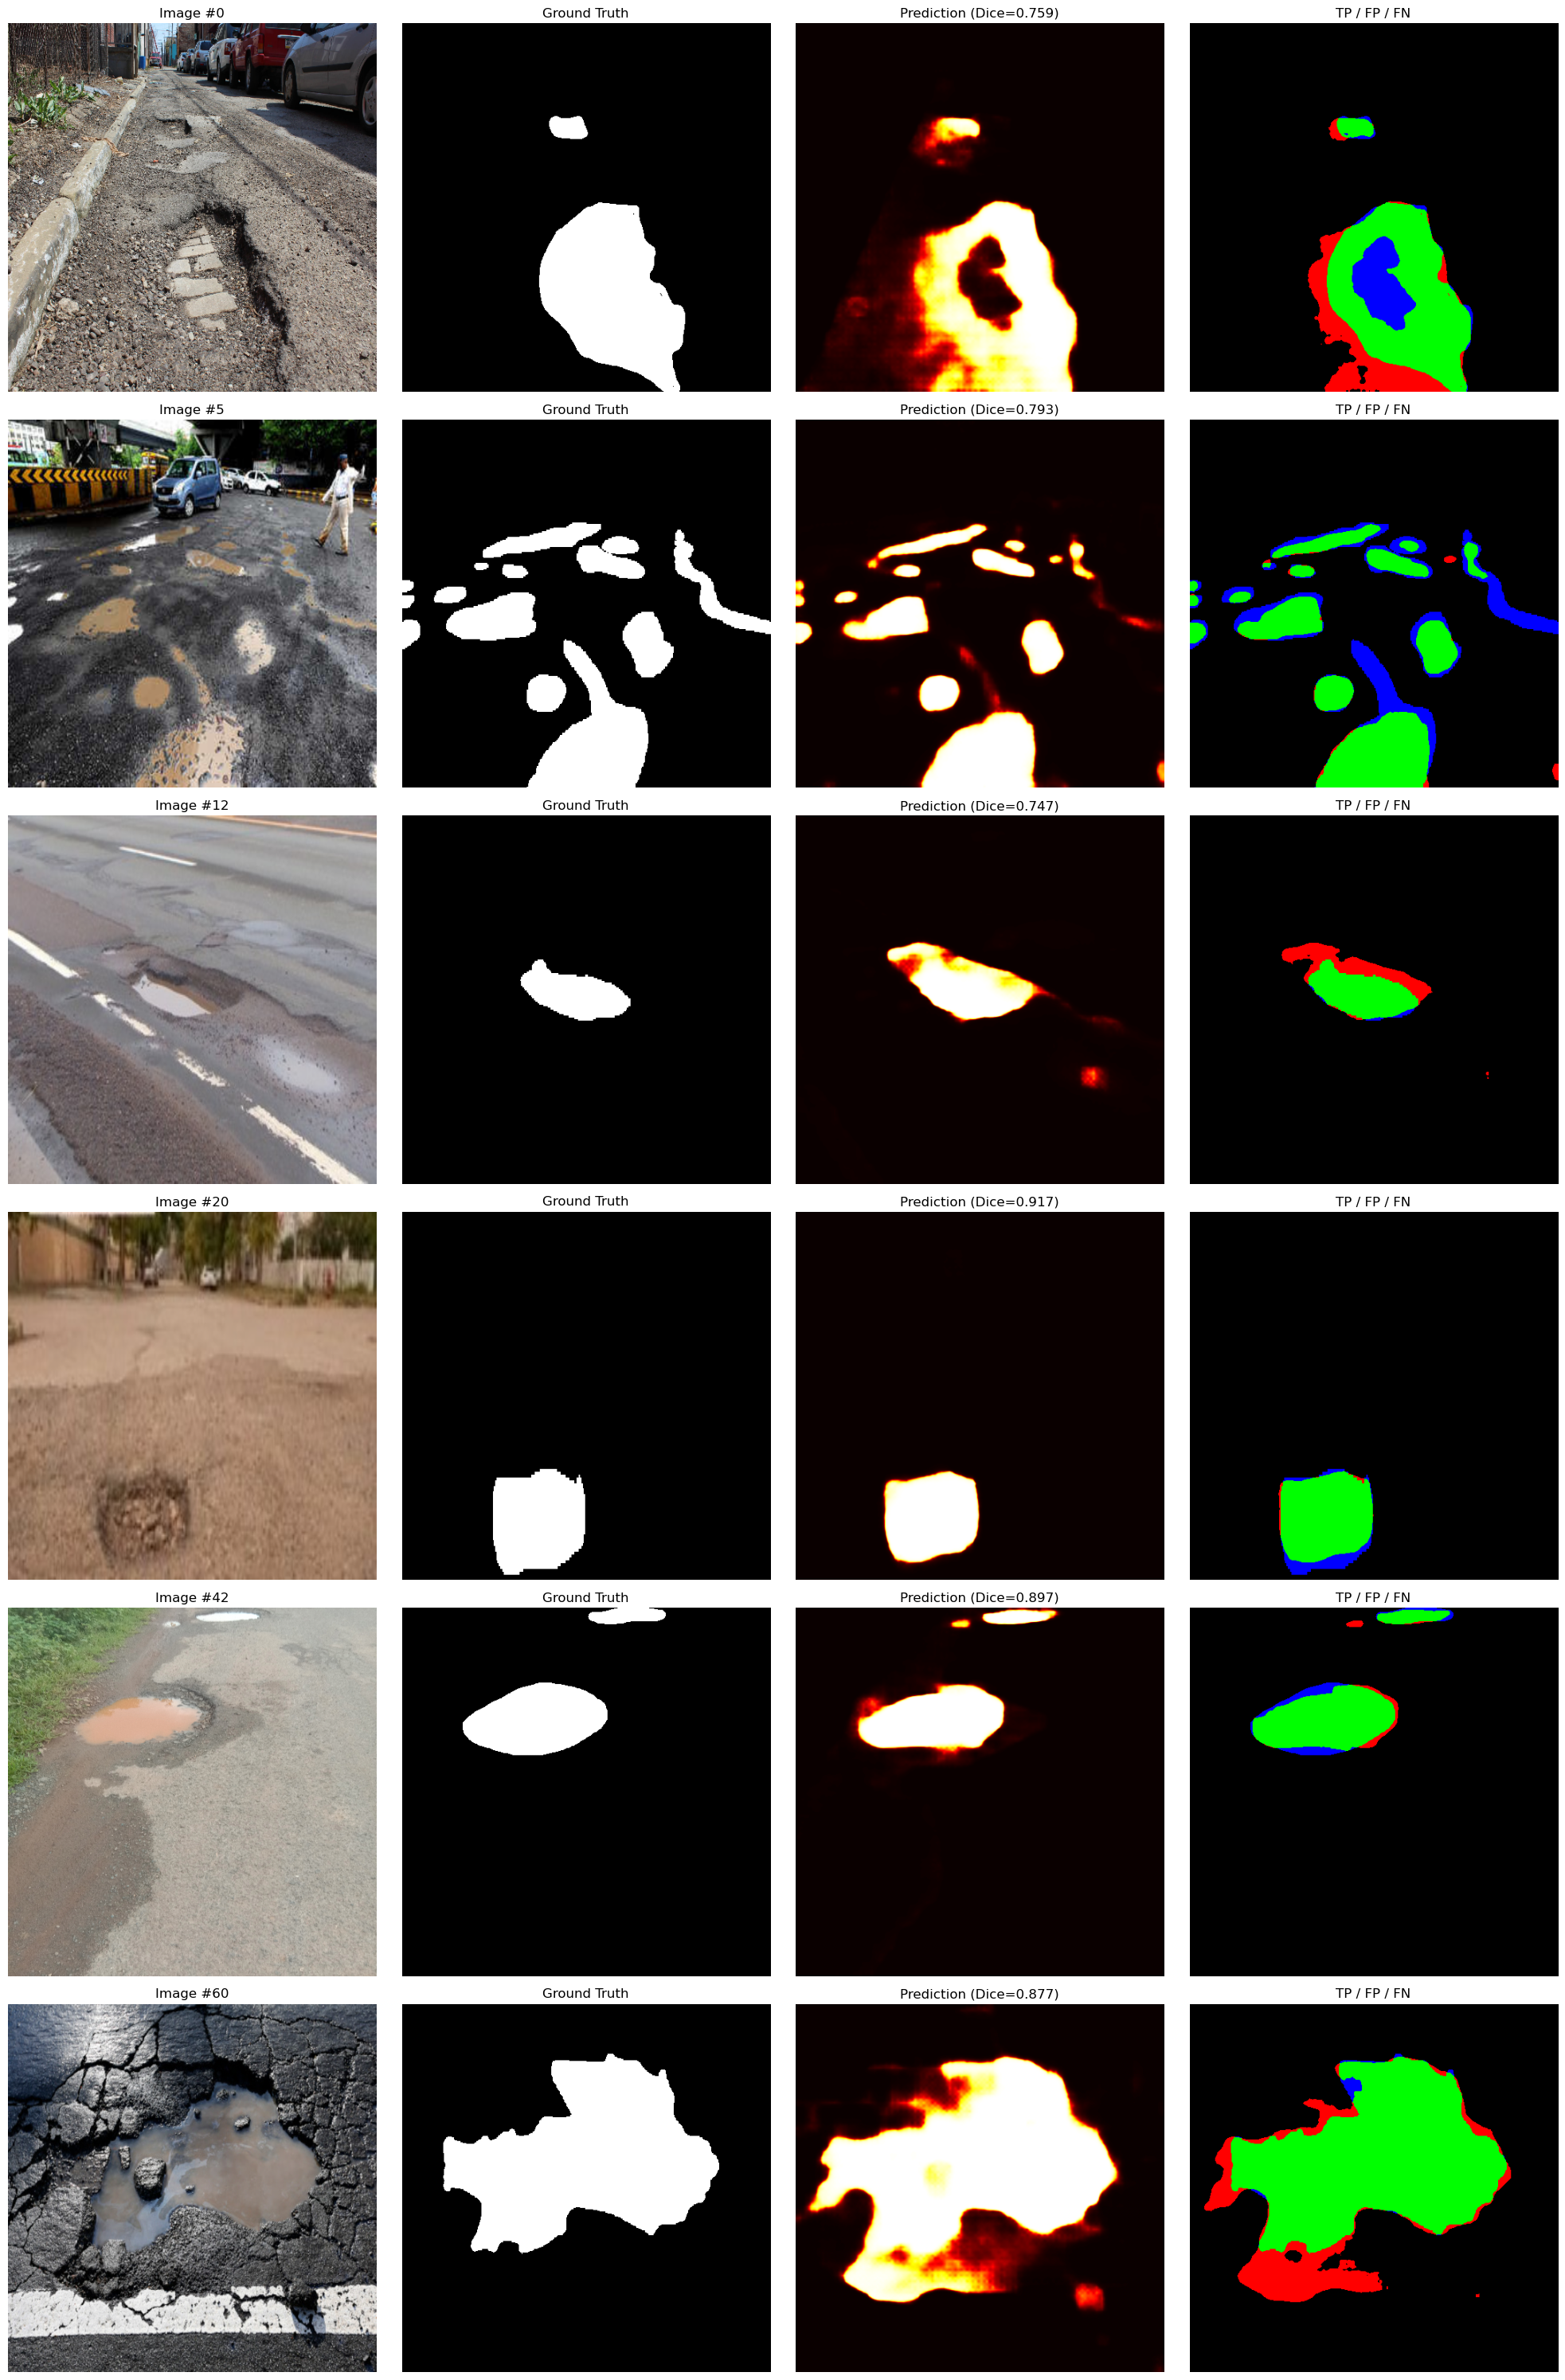

In [43]:
def analyze_split(loader, split_name):
    results = []
    inference_model.eval()
    global_idx = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc=f'Analyzing {split_name}'):
            pv = batch['pixel_values'].to(CFG.DEVICE)
            gt = batch['masks'].to(CFG.DEVICE)

            out  = inference_model(pixel_values=pv)
            pred = combine_query_masks(out, CFG.IMAGE_SIZE)

            for b in range(pred.shape[0]):
                p = pred[b].cpu().numpy()
                g = gt[b].cpu().numpy()
                p_bin = (p > 0.5).astype(np.float32)

                results.append({
                    'dataset_idx': global_idx,
                    'dice': compute_dice(p_bin, g),
                    'iou': compute_iou(p_bin, g),
                    'gt_coverage': g.mean(),
                    'pred_coverage': p_bin.mean(),
                    'avg_confidence': p.mean(),
                    'fp_rate': ((p_bin == 1) & (g == 0)).sum() / max((g == 0).sum(), 1),
                    'fn_rate': ((p_bin == 0) & (g == 1)).sum() / max((g == 1).sum(), 1),
                })

                global_idx += 1

    return pd.DataFrame(results)

val_stats = analyze_split(valid_loader, 'Val')

# Choose validation images to visualize
selected_indices = [0, 5, 12, 20, 42, 60]  #  change freely
selected = val_stats[val_stats['dataset_idx'].isin(selected_indices)]

# Initialize visualization grid
fig, axes = plt.subplots(len(selected), 4, figsize=(20, 5 * len(selected)))

inference_model.eval()
with torch.no_grad():
    for row, (_, r) in enumerate(selected.iterrows()):
        idx = int(r['dataset_idx'])
        sample = valid_dataset[idx]

        pv = sample['pixel_values'].unsqueeze(0).to(CFG.DEVICE)
        gt = sample['mask'].numpy()

        out  = inference_model(pixel_values=pv)
        prob = extract_pred_mask_np(out, 0, CFG.IMAGE_SIZE)
        pred_bin = (prob > 0.5).astype(np.uint8)

        # Denormalize image
        img = sample['pixel_values'].numpy().transpose(1, 2, 0)
        img = np.clip(img * processor.image_std + processor.image_mean, 0, 1)

        # Diff map: TP=Green, FP=Red, FN=Blue
        diff = np.zeros((*gt.shape, 3))
        diff[(pred_bin == 1) & (gt == 1)] = [0, 1, 0]
        diff[(pred_bin == 1) & (gt == 0)] = [1, 0, 0]
        diff[(pred_bin == 0) & (gt == 1)] = [0, 0, 1]

        axes[row,0].imshow(img);  axes[row,0].set_title(f"Image #{idx}"); axes[row,0].axis("off")
        axes[row,1].imshow(gt, cmap="gray"); axes[row,1].set_title("Ground Truth"); axes[row,1].axis("off")
        axes[row,2].imshow(prob, cmap="hot"); axes[row,2].set_title(f"Prediction (Dice={r.dice:.3f})"); axes[row,2].axis("off")
        axes[row,3].imshow(diff); axes[row,3].set_title("TP / FP / FN"); axes[row,3].axis("off")

plt.tight_layout()
plt.show()

Notice how the post analysis shows failure on detecting edge cases, especially in detecting small or ambigous potholes. Future work could focus on enhancing the model's sensitivity to these challenging instances, possibly through targeted class imbalance handling or advanced augmentation techniques.

## Submission

In [45]:
tta_submission_df = pd.DataFrame(tta_submission_results)
tta_submission_file = 'submission_eomt_tta.csv'
tta_submission_df.to_csv(tta_submission_file, index=False)

detected_tta = (tta_submission_df['rle'] != '').sum()
total_tta = len(tta_submission_df)

print(f"TTA Submission saved: {tta_submission_file}")

print(f"TTA Submission Preview:")
print(tta_submission_df.head(10))

TTA Submission saved: submission_eomt_tta.csv
TTA Submission Preview:
        ImageId                                                rle
0  test_001.jpg  5541 4 5840 6 6139 7 6438 9 6738 9 7037 11 733...
1  test_002.jpg  125670 3 126390 5 127109 8 127829 9 128548 11 ...
2  test_003.jpg  516575 3 518870 6 521164 10 523460 12 525755 1...
3  test_004.jpg  34370 4 34666 9 34958 18 35251 27 35549 30 358...
4  test_005.jpg  51129 6 51428 8 51728 9 52028 10 52328 11 5262...
5  test_006.jpg  223 44 523 45 822 47 1122 48 1421 49 1721 49 2...
6  test_007.jpg  826 2 831 1 1125 8 1425 9 1724 10 2024 11 2324...
7  test_008.jpg  142 32 198 39 442 32 498 39 742 33 798 40 1042...
8  test_009.jpg  31895 6 32193 8 32492 10 32791 11 33090 13 333...
9  test_010.jpg  16395 10 16692 17 16990 20 17286 25 17585 27 1...


# Conclusion

## Summary

This notebook presents a complete pipeline for pothole semantic segmentation using the **Encoder-only Mask Transformer (EoMT-DINOv3)**, a streamlined architecture that eliminates traditional pixel decoders and task-specific modules by leveraging a ViT-Large backbone pre-trained with DINOv3's Masked Image Modeling.

### Key Findings from Data Analysis

| Finding | Impact |
|:---|:---|
| **Scale imbalance** — 69.7% "Giant" potholes vs 3.4% "Tiny" | Risk of poor small-defect detection |
| **Center bias** — 59.6% of potholes in frame center | Risk of ignoring peripheral regions |
| **High visual quality** — 100% normal brightness, ~89% sharp | Intensity-degrading augmentations are unnecessary |

### Design Decisions Driven by Analysis

1. **Stratified split** (by mask density bins: <10%, 10–30%, 30–50%, 50%+) ensures rare small-pothole samples are represented in validation.
2. **Geometric-only augmentations** (ShiftScaleRotate with zoom-out bias, GridDistortion, flips, CoarseDropout) — no blur/noise augmentations, preserving the naturally sharp asphalt texture features.
3. **Custom DiceBCE loss** bypassing the model's internal Hungarian matching loss to directly optimize pixel-wise overlap, avoiding NaN instabilities.
4. **Objectness-weighted query combination** — aggregating EoMT's multi-query mask outputs by weighting each query's contribution proportional to `1 − P(no_object)`.
5. **Test-Time Augmentation (TTA)** with horizontal and vertical flips, averaging probability maps for more robust predictions.

### Training Outcome

The model was trained for up to 12 epochs with AdamW optimizer and CosineAnnealing schedule, with early stopping (patience=5) on validation Dice score. The best checkpoint, selected by peak validation Dice, was used for final inference.

